#### **Pipeline Configuration**

In [ ]:
# First, mount the drive and verify that the files exist
from google.colab import drive
drive.mount('/content/drive')

import os

DRIVE_DIR = '/content/drive/MyDrive/DS Capstone Project Team 8/'

# Verify files are there
for f in os.listdir(DRIVE_DIR):
    size = os.path.getsize(DRIVE_DIR + f) / 1e9
    print(f"  {f} — {size:.2f} GB")

Mounted at /content/drive
  event_data_all_perp_80_avg.csv — 0.01 GB
  final_model_data_all_scaled.parquet — 5.63 GB
  results — 0.00 GB
  final_model_data_all_labeled.parquet — 6.11 GB
  FOR EDITING ds_cap_code_model_final.ipynb — 0.00 GB
  fluxes.parquet — 0.98 GB
  flux_chunks — 0.00 GB
  ds_cap_code_model_final.ipynb — 0.00 GB
  Flux Files.ipynb — 0.00 GB
  Copy of Flux Files.ipynb — 0.00 GB
  results_new — 0.00 GB
  results_final — 0.00 GB
  DONT TOUCH ds_cap_code_model_final.ipynb — 0.00 GB
  Research DONT TOUCH ds_cap_code_model_final.ipynb — 0.00 GB


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import glob
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import RobustScaler
from sklearn.metrics import (
    classification_report, roc_auc_score,
    average_precision_score, f1_score,
    roc_curve, confusion_matrix,
    ConfusionMatrixDisplay
)
from xgboost import XGBClassifier

import tensorflow as tf
import keras
from keras import layers, models, metrics, optimizers, losses, callbacks
import dask.dataframe as dd
import dask

B_FEATURE_COLS = [
    'Bx', 'By', 'Bz',
    'Bx_lag_1', 'Bx_lag_2',
    'By_lag_1', 'By_lag_2',
    'Bz_lag_1', 'Bz_lag_2',
    'Bx_conditional_vol', 'By_conditional_vol', 'Bz_conditional_vol',
    'Bx_rolling_stdev',   'By_rolling_stdev',   'Bz_rolling_stdev'
]

epoch_2012_start = 1325376000
epoch_2012_end = 1341100800
epoch_2014_start = 1388534400
epoch_2014_end = 1404172800

FLUX_FEATURE_COLS = [
    # Raw / log electron flux
    'log_PSEF_ch5',
    'rel_PSEF_ch5',
    # Rolling volatility
    'PSEF_ch5_roll_std_short',
    'PSEF_ch5_roll_std_long',
    'PSEF_ch5_vol_ratio',
    # EWMA volatility
    'PSEF_ch5_ewm_std_tanh',
    'log_PSEF_ch5_ewm_std',
    # Rate of change
    'PSEF_ch5_roc_tanh',
    # Longer windows
    'PSEF_ch5_roll_std_5min',
    'PSEF_ch5_injection_ratio',
    # Temporal leads
    'PSEF_ch5_lead_1', 'PSEF_ch5_lead_2', 'PSEF_ch5_lead_3',
]

# CONFIG — change these to adjust the entire pipeline
CONFIG = {
    # Data paths
    'data_path': DRIVE_DIR + 'final_model_data_all_labeled.parquet',
    'event_path': DRIVE_DIR + 'event_data_all_perp_80_avg.csv',
    'flux_dir': DRIVE_DIR + 'flux_chunks/',
    'output_dir': DRIVE_DIR + 'results_new/',

    # Split (Fraction Based)
    'train_satellites': ['THEMIS A', 'THEMIS D'],
    'test_satellite':   'THEMIS E',
    #'val_fraction':     0.15,          # fraction of THD used for validation

    # Split (Year Based)
    'train_years': list(range(2008, 2021)),
    'val_years': [2021, 2022],

    # One-satellite year-package split (all years)
    #'target_satellite': 'THEMIS A',   # change to 'THEMIS D' or 'THEMIS E'
    'train_year_fraction': 0.80,
    'val_year_fraction':   0.20,
    'year_split_seed': 42,

    # Sampling - Year based
    'use_temporal_sampling' : True,
    'train_sample_years': 9,
    'val_sample_years':   5,
    'force_train_years': [2008, 2009, 2010, 2011, 2012, 2013, 2014, 2015, 2016],
    'force_val_years':   [2017, 2018, 2019, 2020, 2021],
    'flux_coverage_years': list(range(2008, 2022)),

    'epoch_train_min' : None,
    'epoch_train_max' : None,
    'epoch_val_min' : None,
    'epoch_val_max' : None,

    # ── Sampling — set to None to use full data ────────────────
    # Use a small fraction first to test pipeline end-to-end
    'sample_fraction': None,    # 5% of data — change to None for full run
    'sample_seed':     42,

    # THE test set sampling - controls memory usage
    'test_sample_fraction' : None,

    # Features
    'feature_cols': B_FEATURE_COLS,
    'b_feature_cols' : B_FEATURE_COLS,
    'flux_feature_cols' : FLUX_FEATURE_COLS,
    'label_col': 'Event_label_80',

    # Evaluation
    'moe_seconds':  180,    # margin of error for event-level detection
    'threshold_min': 0.1,
    'threshold_max': 0.9,
    'threshold_step': 0.01,

    # Flux experiment flag
    'include_flux': True,
}

ALL_FEATURE_COLS = B_FEATURE_COLS + FLUX_FEATURE_COLS

os.makedirs(CONFIG['output_dir'], exist_ok=True)
print("Config loaded.")
print(f"include_flux: {CONFIG['include_flux']}")
print(f"feature_cols: {len(CONFIG['feature_cols'])} features")


Config loaded.
include_flux: True
feature_cols: 15 features


#### **Data Loading, Splitting, Scaling**

In [ ]:
def load_data(config=CONFIG):

    print("Loading event catalog...")
    event_df = pd.read_csv(config['event_path'])
    event_df['start_time'] = pd.to_datetime(event_df['start_time'], utc=True)
    event_df['end_time']   = pd.to_datetime(event_df['end_time'],   utc=True)

    print("Lazy loading parquet (Dask)...")
    cols_needed = (
        config['b_feature_cols']
        + [config['label_col'], 'Epoch_time', 'Satellite']
    )
    df_lazy = dd.read_parquet(config['data_path'], columns=cols_needed)

    # ── Add year lazily ────────────────────────────────────────────────────────
    df_lazy = df_lazy.assign(
        datetime=lambda x: dd.to_datetime(x['Epoch_time'], unit='s', utc=True)
    )
    df_lazy = df_lazy.assign(
        year=lambda x: x['datetime'].dt.year
    )

    if config['use_temporal_sampling']:

        # ── Determine train/val years ──────────────────────────────────────────
        rng       = np.random.default_rng(config['sample_seed'])
        all_years = sorted(df_lazy['year'].unique().compute())
        split_idx = int(len(all_years) * config['train_year_fraction'])

        train_year_pool = all_years[:split_idx]
        val_year_pool   = all_years[split_idx:]

        sampled_train_years = sorted(rng.choice(
            train_year_pool,
            size=min(config['train_sample_years'], len(train_year_pool)),
            replace=False
        ))
        sampled_val_years = sorted(rng.choice(
            val_year_pool,
            size=min(config['val_sample_years'], len(val_year_pool)),
            replace=False
        ))

        # Force override if specified
        if config.get('force_train_years') is not None:
            sampled_train_years = config['force_train_years']
            print(f"Force train years override: {sampled_train_years}")
        if config.get('force_val_years') is not None:
            sampled_val_years = config['force_val_years']
            print(f"Force val years override: {sampled_val_years}")

        config['sampled_train_years'] = sampled_train_years
        config['sampled_val_years']   = sampled_val_years
        sampled_years                 = sampled_train_years + sampled_val_years

        print("\nTemporal sampling enabled.")
        print(f"Train years kept: {sampled_train_years}")
        print(f"Val years kept:   {sampled_val_years}")

        # ── THA + THD: filter by year ──────────────────────────────────────────
        train_val_lazy = df_lazy[
            df_lazy['Satellite'].isin(config['train_satellites']) &
            df_lazy['year'].isin(sampled_years)
        ]

        # ── Apply epoch bounds if specified (6-month filter) ───────────────────
        if config.get('epoch_train_min') and config.get('epoch_val_max'):
            train_val_lazy = train_val_lazy[
                (
                    (train_val_lazy['Epoch_time'] >= config['epoch_train_min']) &
                    (train_val_lazy['Epoch_time'] <= config['epoch_train_max']) &
                    (train_val_lazy['year'].isin(sampled_train_years))
                ) |
                (
                    (train_val_lazy['Epoch_time'] >= config['epoch_val_min']) &
                    (train_val_lazy['Epoch_time'] <= config['epoch_val_max']) &
                    (train_val_lazy['year'].isin(sampled_val_years))
                )
            ]
            print(f"Epoch filter applied:")
            print(f"  Train: "
                  f"{pd.Timestamp(config['epoch_train_min'], unit='s', tz='UTC').date()} → "
                  f"{pd.Timestamp(config['epoch_train_max'], unit='s', tz='UTC').date()}")
            print(f"  Val:   "
                  f"{pd.Timestamp(config['epoch_val_min'], unit='s', tz='UTC').date()} → "
                  f"{pd.Timestamp(config['epoch_val_max'], unit='s', tz='UTC').date()}")

        # ── THE: filter to flux-covered years if needed ────────────────────────
        the_lazy = df_lazy[df_lazy['Satellite'] == config['test_satellite']]
        if config.get('include_flux', False):
            flux_years_available = config.get('flux_coverage_years',
                                              list(range(2008, 2022)))
            the_lazy = the_lazy[the_lazy['year'].isin(flux_years_available)]
            print(f"THE restricted to flux-covered years: {flux_years_available}")

        # ── Compute THA+THD first ──────────────────────────────────────────────
        print("\nComputing THA+THD...")
        train_val_df = train_val_lazy.compute().reset_index(drop=True)
        print(f"THA+THD rows: {len(train_val_df):,}")

        # ── Compute THE with stratified sampling ───────────────────────────────
        print("Computing THE...")
        if config.get('test_sample_fraction') is not None:
            the_df_full = the_lazy.compute().reset_index(drop=True)
            the_df = (the_df_full
                      .groupby('year', group_keys=False)
                      .apply(lambda x: x.sample(
                          frac=config['test_sample_fraction'],
                          random_state=config['sample_seed']
                      ))
                      .reset_index(drop=True))
            print(f"THE stratified {config['test_sample_fraction']*100:.0f}% per year:")
            print(the_df.groupby('year').size().to_string())
            del the_df_full
            import gc
            gc.collect()
        else:
            the_df = the_lazy.compute().reset_index(drop=True)

        print(f"THE rows: {len(the_df):,}")

        df = pd.concat([train_val_df, the_df], ignore_index=True)
        print(f"\nTHA+THD rows: {len(train_val_df):,}")
        print(f"THE rows:     {len(the_df):,}")

    else:
        df = df_lazy.compute().reset_index(drop=True)

    print(f"\nLoaded: {df.shape}")
    print(f"Memory: {df.memory_usage(deep=True).sum()/1e9:.2f} GB")
    print(f"Satellites: {df['Satellite'].value_counts().to_dict()}")
    print(f"Label balance: "
          f"{df[config['label_col']].value_counts(normalize=True).round(3).to_dict()}")

    # ── Flux loading and merging ───────────────────────────────────────────────
    if config.get('include_flux', False):
        flux_years = (config.get('sampled_train_years', []) +
                      config.get('sampled_val_years',   []))

        sat_suffix_map = {'THEMIS A': 'THA', 'THEMIS D': 'THD', 'THEMIS E': 'THE'}
        all_sats  = config['train_satellites'] + [config['test_satellite']]
        flux_sats = [sat_suffix_map[s] for s in all_sats]

        flux_df = load_flux_files(
            config['flux_dir'],
            year_filter = flux_years,
            satellites  = flux_sats,
            epoch_min   = config.get('epoch_train_min') or df['Epoch_time'].min(),
            epoch_max   = config.get('epoch_val_max')   or df['Epoch_time'].max()
        )
        df = merge_flux(df, flux_df)

        del flux_df
        import gc
        gc.collect()
        print("Flux df freed from memory")

        df = engineer_flux_features(df, config)

        n_before = len(df)
        df = df.dropna(subset=['PSEF_ch5']).reset_index(drop=True)
        print(f"Dropped {n_before - len(df):,} rows with missing electron flux")

        print(f"Feature cols: {len(config['feature_cols'])} total features")

    return df, event_df

In [ ]:
# ════════════════════════════════════════════════════════════
# FLUX DATA: LOAD, MERGE, FEATURE ENGINEERING
# ════════════════════════════════════════════════════════════

# ════════════════════════════════════════════════════════════
# UPDATED FLUX FUNCTIONS — satellite-aware
# Handles filenames: flux_2020-12-31_2021-12-31_THA.parquet
#                    flux_2020-12-31_2021-12-31_THE.parquet
#                    flux_2020-12-31_2021-12-31_THD.parquet
# ════════════════════════════════════════════════════════════

FLUX_RAW_COLS = ['time', 'PSEF_ch5',
                  'rel_PSEF_ch5',
                  'log_PSEF_ch5']

# Satellite name in flux filename → Satellite column value in main df
FLUX_SAT_MAP = {
    'THA': 'THEMIS A',
    'THD': 'THEMIS D',
    'THE': 'THEMIS E',
}

def load_flux_files(flux_dir, year_filter=None, satellites=None,
                    epoch_min=None, epoch_max=None):
    """
    Load satellite-specific flux files.
    Filename pattern: flux_YYYY-MM-DD_YYYY-MM-DD_SAT.parquet
    where SAT is THA, THD, or THE.

    year_filter:  list of ints  — only load files overlapping those years
    satellites:   list of strs  — e.g. ['THA', 'THD', 'THE']
                                  None = load all satellites
    """
    flux_files = sorted(glob.glob(flux_dir + 'flux_*.parquet'))
    print(f"\nFound {len(flux_files)} flux files total")

    filtered = []
    for f in flux_files:
        basename = os.path.basename(f)
        name     = os.path.splitext(basename)[0]   # flux_2020-12-31_2021-12-31_THA
        parts    = name.split('_')
        # parts: ['flux', '2020-12-31', '2021-12-31', 'THA']

        # ── Handle both old format (no sat suffix) and new format ─────────────
        # In load_flux_files, replace the parsing block with:
        if len(parts) == 4:
            # New format: flux_DATE_DATE_SAT
            yr_start = int(parts[1][:4])
            yr_end   = int(parts[2][:4])
            sat      = parts[3]              # 'THA', 'THD', or 'THE'
        elif len(parts) == 3:
            # Old format: flux_DATE_DATE — assumed to be THA
            yr_start = int(parts[1][:4])
            yr_end   = int(parts[2][:4])
            sat      = 'THA'                 # ← assume THA, not None
        else:
            continue

        # Year filter
        if year_filter is not None:
            if not any(yr_start <= y <= yr_end for y in year_filter):
                continue

        # Satellite filter — THA assumed for no-suffix files
        if satellites is not None:
            if sat not in satellites:
                continue

        filtered.append((f, sat))

    print(f"After filters: {len(filtered)} files kept")
    for f, sat in filtered:
        print(f"  {os.path.basename(f)} → satellite: {sat}")

    if not filtered:
        raise ValueError("No flux files found — check flux_dir, year_filter, satellites")

    # ── Load each file and tag with satellite ─────────────────────────────────
    dfs = []
    for f, sat in filtered:
        df_f = pd.read_parquet(f, columns=FLUX_RAW_COLS)
        df_f = df_f.rename(columns={'time': 'Epoch_time'})

        if epoch_min is not None:
            df_f = df_f[df_f['Epoch_time'] >= epoch_min]
        if epoch_max is not None:
            df_f = df_f[df_f['Epoch_time'] <= epoch_max]

        # Tag with satellite so merge can be satellite-aware
        if sat is not None:
            df_f['flux_satellite'] = FLUX_SAT_MAP.get(sat, sat)
        else:
            df_f['flux_satellite'] = None   # old format — no sat info

        dfs.append(df_f)

        import gc
        gc.collect()   # ← add this

    flux_df = pd.concat(dfs, ignore_index=True)
    flux_df = (flux_df
               .sort_values('Epoch_time')
               .drop_duplicates(subset=['Epoch_time', 'flux_satellite'])
               .reset_index(drop=True))

    print(f"\nFlux loaded: {flux_df.shape}")
    print(f"Epoch range: {flux_df['Epoch_time'].min():.0f} → "
          f"{flux_df['Epoch_time'].max():.0f}")
    print(f"Date range:  "
          f"{pd.Timestamp(flux_df['Epoch_time'].min(), unit='s', tz='UTC')} → "
          f"{pd.Timestamp(flux_df['Epoch_time'].max(), unit='s', tz='UTC')}")
    if 'flux_satellite' in flux_df.columns:
        print(f"Satellites:  {flux_df['flux_satellite'].value_counts().to_dict()}")
    print(f"NaN counts:\n{flux_df.iloc[:, 1:-1].isna().sum().to_string()}")
    return flux_df


def merge_flux(main_df, flux_df, tolerance_seconds=30):
    """
    Satellite-aware flux merge.
    If flux_df has satellite tags, merge per satellite to avoid
    THA flux being matched to THD timestamps.
    """
    print(f"\nMerging flux (satellite-aware)...")
    print(f"  Main: {len(main_df):,} rows | Flux: {len(flux_df):,} rows")

    flux_cols = ['Epoch_time', 'flux_satellite', 'PSEF_ch5',
                  'rel_PSEF_ch5',
                  'log_PSEF_ch5']

    has_sat_info = ('flux_satellite' in flux_df.columns and
                    flux_df['flux_satellite'].notna().any())

    if has_sat_info:
        # ── Satellite-aware: merge each satellite separately ──────────────────
        merged_parts = []
        for sat in main_df['Satellite'].unique():
            main_sat  = (main_df[main_df['Satellite'] == sat]
                         .sort_values('Epoch_time')
                         .reset_index(drop=True))
            flux_sat  = (flux_df[flux_df['flux_satellite'] == sat]
                         [flux_cols]
                         .sort_values('Epoch_time')
                         .reset_index(drop=True))

            if len(flux_sat) == 0:
                print(f"  ⚠ No flux data for {sat} — flux cols will be NaN")
                merged_parts.append(main_sat)
                continue

            merged_sat = pd.merge_asof(
                main_sat, flux_sat.drop(columns=['flux_satellite']),
                on='Epoch_time',
                direction='nearest',
                tolerance=tolerance_seconds
            )
            n_matched = merged_sat['PSEF_ch5'].notna().sum()
            print(f"  {sat}: {n_matched:,}/{len(merged_sat):,} matched "
                  f"({n_matched/len(merged_sat)*100:.1f}%)")
            merged_parts.append(merged_sat)

        merged = pd.concat(merged_parts, ignore_index=True)

    else:
        # ── Fallback: old format with no satellite info ────────────────────────
        print("  No satellite info in flux — using epoch-only merge (old behavior)")
        main_s = main_df.sort_values('Epoch_time').reset_index(drop=True)
        flux_s = (flux_df[['Epoch_time', 'PSEF_ch5',
                             'rel_PSEF_ch5',
                             'log_PSEF_ch5']]
                  .sort_values('Epoch_time').reset_index(drop=True))
        merged = pd.merge_asof(
            main_s, flux_s,
            on='Epoch_time',
            direction='nearest',
            tolerance=tolerance_seconds
        )

    n_matched   = merged['PSEF_ch5'].notna().sum()
    n_unmatched = merged['PSEF_ch5'].isna().sum()
    print(f"\n  Total matched:   {n_matched:,} ({n_matched/len(merged)*100:.1f}%)")
    print(f"  Total unmatched: {n_unmatched:,} ({n_unmatched/len(merged)*100:.1f}%)")
    return merged


def engineer_flux_features(df, config=CONFIG):
    """
    Feature engineering for flux — mirrors the magnetic field approach:
    rolling std (short + long), EWMA volatility, rate of change,
    volatility ratio, and ion/electron ratio.
    """
    print("\nEngineering flux features...")
    df = df.copy()

    time_unix  = df['Epoch_time'].values
    seq_groups = pd.Series(
        (pd.Series(time_unix).diff() > 300).cumsum().values,
        index=df.index
    )

    for col in ['PSEF_ch5', 'rel_PSEF_ch5']:
        if col not in df.columns or df[col].isna().all():
            print(f"  Skipping {col} — all NaN")
            continue

        # ── FIX: use max() instead of .clip() on a float ──────────────────────
        std_scale = max(df[col].std(skipna=True), 1e-6)

        df[f'{col}_roll_std_short'] = (df.groupby(seq_groups)[col]
            .transform(lambda x: x.rolling(9,  min_periods=1, center=True).std()))
        df[f'{col}_roll_std_long']  = (df.groupby(seq_groups)[col]
            .transform(lambda x: x.rolling(50, min_periods=1, center=True).std()))
        df[f'{col}_vol_ratio']      = (df[f'{col}_roll_std_short'] /
                                        df[f'{col}_roll_std_long'].replace(0, np.nan))
        df[f'{col}_ewm_std']        = (df.groupby(seq_groups)[col]
            .transform(lambda x: x.ewm(span=20, min_periods=1).std()))
        df[f'{col}_ewm_std_tanh']   = np.tanh(df[f'{col}_ewm_std'] / std_scale)
        df[f'{col}_roc']            = (df.groupby(seq_groups)[col]
            .transform(lambda x: x.diff(2) / 2))
        df[f'{col}_roc_tanh']       = np.tanh(df[f'{col}_roc'] / std_scale)

    for col in ['log_PSEF_ch5']:
        if col in df.columns:
            df[f'{col}_ewm_std'] = (df.groupby(seq_groups)[col]
                .transform(lambda x: x.ewm(span=20, min_periods=1).std()))

    # ── Extended windows — longer lookback for injection signatures ────────────
    for col in ['PSEF_ch5']:
        if col not in df.columns or df[col].isna().all():
            continue

        std_scale = max(df[col].std(skipna=True), 1e-6)

        # 5 minute window (~100 points at 3s cadence)
        df[f'{col}_roll_std_5min'] = (df.groupby(seq_groups)[col]
            .transform(lambda x: x.rolling(100, min_periods=1).std()))

        # Injection ratio: short-term spike vs 5min background
        # High value = sudden injection above background = BBF signature
        df[f'{col}_injection_ratio'] = np.tanh(
            df[f'{col}_roll_std_short'] /
            df[f'{col}_roll_std_5min'].replace(0, np.nan)
        )

    # ── Temporal lead — flux precedes B field dipolarization ──────────────────
    # Energetic particles travel faster than Alfven speed
    # so flux spikes slightly before the B field signature
    for col in ['PSEF_ch5']:
        if col in df.columns:
            for lead in [1, 2, 3]:   # 3s, 6s, 9s lead
                df[f'{col}_lead_{lead}'] = (
                    df.groupby(seq_groups)[col]
                    .shift(-lead)
                )

    new_cols = [c for c in df.columns if 'PSEF' in c]
    print(f"  Added {len(new_cols)} electron flux feature columns")
    return df

In [ ]:
'''
# ════════════════════════════════════════════════════════════
# LOADING DATA with Random Subsampling
# Reconstructs Satellite column from event catalog
# ════════════════════════════════════════════════════════════
def load_data(config=CONFIG):
    """
    Load dataset and event catalog.
    Satellite column already present in labeled parquet.
    """
    print("Loading event catalog...")
    event_df = pd.read_csv(config['event_path'])
    event_df['start_time']  = pd.to_datetime(event_df['start_time'], utc=True)
    event_df['end_time']    = pd.to_datetime(event_df['end_time'],   utc=True)
    event_df['start_epoch'] = event_df['start_time'].apply(lambda x: x.timestamp())
    event_df['end_epoch']   = event_df['end_time'].apply(lambda x: x.timestamp())

    # ── Lazy load — only pull columns we need ─────────────────
    print("Lazy loading parquet...")
    cols_needed = (config['feature_cols'] +
                   [config['label_col'], 'Epoch_time', 'Satellite'])

    df_lazy = dd.read_parquet(config['data_path'], columns=cols_needed)

    # ── Sample to keep things small during testing ─────────────
    if config['sample_fraction'] is not None:
        print(f"Sampling {config['sample_fraction']*100:.0f}% of data...")
        df = (df_lazy
              .sample(frac=config['sample_fraction'],
                      random_state=config['sample_seed'])
              .compute()
              .reset_index(drop=True))
    else:
        print("Loading full dataset...")
        df = df_lazy.compute().reset_index(drop=True)

    print(f"Loaded:        {df.shape}")
    print(f"Memory:        {df.memory_usage(deep=True).sum()/1e9:.2f} GB")
    print(f"Satellites:    {df['Satellite'].value_counts().to_dict()}")
    print(f"Label balance: {df[config['label_col']].value_counts(normalize=True).round(3).to_dict()}")

    return df, event_df
  '''

'\n# ════════════════════════════════════════════════════════════\n# LOADING DATA with Random Subsampling\n# Reconstructs Satellite column from event catalog\n# ════════════════════════════════════════════════════════════\ndef load_data(config=CONFIG):\n    """\n    Load dataset and event catalog.\n    Satellite column already present in labeled parquet.\n    """\n    print("Loading event catalog...")\n    event_df = pd.read_csv(config[\'event_path\'])\n    event_df[\'start_time\']  = pd.to_datetime(event_df[\'start_time\'], utc=True)\n    event_df[\'end_time\']    = pd.to_datetime(event_df[\'end_time\'],   utc=True)\n    event_df[\'start_epoch\'] = event_df[\'start_time\'].apply(lambda x: x.timestamp())\n    event_df[\'end_epoch\']   = event_df[\'end_time\'].apply(lambda x: x.timestamp())\n\n    # ── Lazy load — only pull columns we need ─────────────────\n    print("Lazy loading parquet...")\n    cols_needed = (config[\'feature_cols\'] +\n                   [config[\'label_col\'], \'

In [ ]:
'''
# ════════════════════════════════════════════════════════════
# LOADING DATA with Contiguous Block Sampling
# Reconstructs Satellite column from event catalog
# ════════════════════════════════════════════════════════════
def load_data(config=CONFIG, block_size_hours=24):
    """
    Load dataset and event catalog using Contiguous Block Sampling.
    """
    print("Loading event catalog...")
    event_df = pd.read_csv(config['event_path'])
    # ... (Keep your existing datetime conversion code here) ...

    print("Lazy loading parquet...")
    cols_needed = (config['feature_cols'] +
                   [config['label_col'], 'Epoch_time', 'Satellite'])
    df_lazy = dd.read_parquet(config['data_path'], columns=cols_needed)

    if config['sample_fraction'] is not None:
        print(f"Sampling {config['sample_fraction']*100:.0f}% of data in {block_size_hours}h blocks...")

        # 1. Determine the full time range without loading the whole 5.6GB
        time_min, time_max = dask.compute(df_lazy['Epoch_time'].min(), df_lazy['Epoch_time'].max())

        # 2. Create potential block starts
        block_size_sec = block_size_hours * 3600
        total_duration = time_max - time_min
        num_possible_blocks = int(total_duration / block_size_sec)

        # 3. Randomly select which blocks to load
        num_to_sample = max(1, int(num_possible_blocks * config['sample_fraction']))
        rng = np.random.default_rng(config['sample_seed'])
        selected_indices = sorted(rng.choice(num_possible_blocks, size=num_to_sample, replace=False))

        sampled_frames = []
        print(f"\n--- Loading {num_to_sample} Specific Blocks ---")
        for idx in selected_indices:
            b_start = time_min + (idx * block_size_sec)
            b_end = b_start + block_size_sec

            # Print specific block info for your logs
            readable_start = pd.to_datetime(b_start, unit='s', utc=True).strftime('%Y-%m-%d %H:%M')
            print(f"  [Block {idx:04d}]: {readable_start} (Duration: {block_size_hours}h)")

            # Filter and add to list
            block_df = df_lazy[(df_lazy['Epoch_time'] >= b_start) & (df_lazy['Epoch_time'] < b_end)]
            sampled_frames.append(block_df)

        # 4. Compute only the selected slices
        df = dd.concat(sampled_frames).compute().reset_index(drop=True)
        print("--- Block Loading Complete ---\n")
    else:
        print("Loading full dataset...")
        df = df_lazy.compute().reset_index(drop=True)

    # Standard summary prints you already had
    print(f"Loaded:        {df.shape}")
    print(f"Memory:        {df.memory_usage(deep=True).sum()/1e9:.2f} GB")
    print(f"Satellites:    {df['Satellite'].value_counts().to_dict()}")
    print(f"Label balance: {df[config['label_col']].value_counts(normalize=True).round(3).to_dict()}")

    return df, event_df
'''

'\n# ════════════════════════════════════════════════════════════\n# LOADING DATA with Contiguous Block Sampling\n# Reconstructs Satellite column from event catalog\n# ════════════════════════════════════════════════════════════\ndef load_data(config=CONFIG, block_size_hours=24):\n    """\n    Load dataset and event catalog using Contiguous Block Sampling.\n    """\n    print("Loading event catalog...")\n    event_df = pd.read_csv(config[\'event_path\'])\n    # ... (Keep your existing datetime conversion code here) ...\n\n    print("Lazy loading parquet...")\n    cols_needed = (config[\'feature_cols\'] +\n                   [config[\'label_col\'], \'Epoch_time\', \'Satellite\'])\n    df_lazy = dd.read_parquet(config[\'data_path\'], columns=cols_needed)\n\n    if config[\'sample_fraction\'] is not None:\n        print(f"Sampling {config[\'sample_fraction\']*100:.0f}% of data in {block_size_hours}h blocks...")\n\n        # 1. Determine the full time range without loading the whole 5.6GB\

In [ ]:
'''
# First Method: Last fraction of THD in validation set chronologically

# ════════════════════════════════════════════════════════════
# PART 2: SPLITTING DATA
# ════════════════════════════════════════════════════════════

def split_data(df, config=CONFIG):
    """
    Satellite-based train/val/test split.

    Train → THEMIS A + THEMIS D (all data)
    Val   → Last val_fraction of THEMIS D chronologically
    Test  → THEMIS E (completely held out — never seen in training)

    This guarantees:
    - All event timestamps stay in one split
    - No temporal overlap between train and test
    - True out-of-sample generalization test
    """
    print("\nSplitting data...")

    # ── Test: held-out satellite ───────────────────────────────
    test_df = df[df['Satellite'] == config['test_satellite']].reset_index(drop=True)

    # ── Sort each satellite by time before splitting ───────────
    tha = (df[df['Satellite'] == 'THEMIS A']
           .sort_values('Epoch_time')
           .reset_index(drop=True))
    thd = (df[df['Satellite'] == 'THEMIS D']
           .sort_values('Epoch_time')
           .reset_index(drop=True))

    # ── Val: last val_fraction of THD chronologically ─────────
    val_cut  = int((1 - config['val_fraction']) * len(thd))
    thd_tr   = thd.iloc[:val_cut].reset_index(drop=True)
    val_df   = thd.iloc[val_cut:].reset_index(drop=True)

    # ── Train: all THA + early THD ────────────────────────────
    train_df = pd.concat([tha, thd_tr], ignore_index=True)

    # ── Verify temporal integrity ──────────────────────────────
    thd_tr_end  = pd.Timestamp(thd_tr['Epoch_time'].max(), unit='s', tz='UTC')
    val_start   = pd.Timestamp(val_df['Epoch_time'].min(), unit='s', tz='UTC')
    no_overlap  = thd_tr_end < val_start

    print(f"  THD train ends:      {thd_tr_end}")
    print(f"  THD val starts:      {val_start}")
    print(f"  Temporal integrity:  {'✓ PASSED' if no_overlap else '✗ FAILED'}")
    print()
    print(f"  Train (THA+THD): {len(train_df):,} | {train_df[config['label_col']].mean()*100:.1f}% events")
    print(f"  Val   (THD end): {len(val_df):,}   | {val_df[config['label_col']].mean()*100:.1f}% events")
    print(f"  Test  (THE):     {len(test_df):,}  | {test_df[config['label_col']].mean()*100:.1f}% events")

    return train_df, val_df, test_df
  '''

'\n# First Method: Last fraction of THD in validation set chronologically\n\n# ════════════════════════════════════════════════════════════\n# PART 2: SPLITTING DATA\n# ════════════════════════════════════════════════════════════\n\ndef split_data(df, config=CONFIG):\n    """\n    Satellite-based train/val/test split.\n\n    Train → THEMIS A + THEMIS D (all data)\n    Val   → Last val_fraction of THEMIS D chronologically\n    Test  → THEMIS E (completely held out — never seen in training)\n\n    This guarantees:\n    - All event timestamps stay in one split\n    - No temporal overlap between train and test\n    - True out-of-sample generalization test\n    """\n    print("\nSplitting data...")\n\n    # ── Test: held-out satellite ───────────────────────────────\n    test_df = df[df[\'Satellite\'] == config[\'test_satellite\']].reset_index(drop=True)\n\n    # ── Sort each satellite by time before splitting ───────────\n    tha = (df[df[\'Satellite\'] == \'THEMIS A\']\n           .sort_v

In [ ]:
# Second Method: Clear year based splitting for training and validation sets
# Use this for now

def split_data(df, config=CONFIG):
    """
    Satellite + year based split.

    Train → THA + THD, years 2008-2020
    Val   → THA + THD, years 2021-2022
            (both satellites, clean temporal boundary,
             no contemporaneous overlap with train)
    Test  → THEMIS E entirely (held-out satellite, all years)

    This guarantees:
    - Clean temporal boundary between train and val
    - Both satellites represented in val (no THD-only bias)
    - THE completely unseen during training and validation
    - All event timestamps stay within one split
    """
    print("\nSplitting data...")

    if config['use_temporal_sampling']:
        train_years = config['sampled_train_years']
        val_years   = config['sampled_val_years']
    else:
        train_years = config['train_years']
        val_years   = config['val_years']

    # ── Test: held-out satellite — no year filter ──────────────
    test_df = (df[df['Satellite'] == config['test_satellite']]
               .sort_values('Epoch_time')
               .reset_index(drop=True))

    # ── Canonical epoch filter — for controlled ablation experiment ────────────
    # When set, restricts THE test rows to exactly the epochs that had
    # matched flux in Run 1, guaranteeing identical test sets across both runs.
    if config.get('canonical_test_epochs') is not None:
        before = len(test_df)
        test_df = (test_df[test_df['Epoch_time']
                   .isin(config['canonical_test_epochs'])]
                   .reset_index(drop=True))
        print(f"  Canonical epoch filter: {before:,} → {len(test_df):,} THE rows")

    # ── Add year column to THA + THD only ─────────────────────
    train_val = df[df['Satellite'].isin(config['train_satellites'])].copy()
    train_val['year'] = pd.to_datetime(
        train_val['Epoch_time'], unit='s'
    ).dt.year

    # ── Train: THA + THD up to 2020 ───────────────────────────
    train_df = (train_val[train_val['year'].isin(train_years)]
                .sort_values('Epoch_time')
                .reset_index(drop=True))

    # ── Val: THA + THD 2021-2022 ──────────────────────────────
    val_df   = (train_val[train_val['year'].isin(val_years)]
                .sort_values('Epoch_time')
                .reset_index(drop=True))

    # ── Verify temporal integrity ──────────────────────────────
    train_end = train_df['Epoch_time'].max()
    val_start = val_df['Epoch_time'].min()
    no_overlap = train_end < val_start

    print(f"  Train ends:          "
          f"{pd.Timestamp(train_end, unit='s', tz='UTC')}")
    print(f"  Val starts:          "
          f"{pd.Timestamp(val_start, unit='s', tz='UTC')}")
    print(f"  Temporal integrity:  "
          f"{'✓ PASSED' if no_overlap else '✗ FAILED'}")
    print()

    # ── Safety check before percentage printing ─────────────────
    if len(train_df) == 0:
        raise ValueError(
            f"train_df is empty. Train years={train_years}. "
            "Check temporal sampling, flux coverage, and dropna after flux merge."
        )

    if len(val_df) == 0:
        raise ValueError(
            f"val_df is empty. Val years={val_years}. "
            "Most likely these validation years have no matched flux after dropna. "
            "Try forcing validation years that have flux files, or temporarily set include_flux=False."
        )

    if len(test_df) == 0:
        raise ValueError(
            f"test_df is empty for {config['test_satellite']}. "
            "Check test satellite and flux coverage."
        )

    # ── Satellite breakdown within each split ──────────────────
    print("  Train breakdown:")
    for sat in config['train_satellites']:
        n = (train_df['Satellite'] == sat).sum()
        print(f"    {sat}: {n:,} ({n/len(train_df)*100:.1f}%)")

    print("  Val breakdown:")
    for sat in config['train_satellites']:
        n = (val_df['Satellite'] == sat).sum()
        print(f"    {sat}: {n:,} ({n/len(val_df)*100:.1f}%)")

    print()
    print(f"  Train years: {train_years}")
    print(f"  Val years:   {val_years}")

    print(f"\n  Train: "
          f"{len(train_df):,} | "
          f"{train_df[config['label_col']].mean()*100:.1f}% events")

    print(f"  Val:   "
          f"{len(val_df):,} | "
          f"{val_df[config['label_col']].mean()*100:.1f}% events")

    print(f"  Test:  "
          f"{len(test_df):,} | "
          f"{test_df[config['label_col']].mean()*100:.1f}% events")

    return train_df, val_df, test_df

In [ ]:
'''
def split_data(df, config=CONFIG):
    """
    One-satellite random year-package split.

    Use only one satellite.
    Randomly assign whole years:
        80% of available years -> training
        20% of available years -> validation

    The validation set is untouched during training.
    """
    print("\nSplitting one satellite by whole-year packages...")

    sat = config['target_satellite']

    df_sat = df[df['Satellite'] == sat].copy()

    if len(df_sat) == 0:
        raise ValueError(f"No data found for {sat}")

    df_sat['year'] = pd.to_datetime(
        df_sat['Epoch_time'],
        unit='s',
        utc=True
    ).dt.year

    years = np.array(sorted(df_sat['year'].dropna().unique()))

    rng = np.random.default_rng(config['year_split_seed'])
    rng.shuffle(years)

    n_years = len(years)
    n_train = int(np.floor(config['train_year_fraction'] * n_years))

    # Make sure both train and validation get at least one year
    n_train = max(1, min(n_train, n_years - 1))

    train_years = sorted(years[:n_train])
    val_years   = sorted(years[n_train:])

    train_df = (
        df_sat[df_sat['year'].isin(train_years)]
        .sort_values('Epoch_time')
        .reset_index(drop=True)
    )

    val_df = (
        df_sat[df_sat['year'].isin(val_years)]
        .sort_values('Epoch_time')
        .reset_index(drop=True)
    )

    # No separate test set in this setup.
    # To keep the original pipeline unchanged, use validation as test_df too.
    test_df = val_df.copy()

    print(f"\nSatellite: {sat}")
    print(f"Available years: {sorted(years)}")
    print(f"Train years ({len(train_years)} years): {train_years}")
    print(f"Val years   ({len(val_years)} years): {val_years}")

    total = len(train_df) + len(val_df)

    print("\nSplit summary:")
    print(f"  Train: {len(train_df):,} rows | {len(train_df) / total * 100:.2f}%")
    print(f"  Val:   {len(val_df):,} rows | {len(val_df) / total * 100:.2f}%")

    print("\nEvent-label balance:")
    print(f"  Train: {train_df[config['label_col']].mean() * 100:.2f}% events")
    print(f"  Val:   {val_df[config['label_col']].mean() * 100:.2f}% events")

    return train_df, val_df, test_df
'''

'\ndef split_data(df, config=CONFIG):\n    """\n    One-satellite random year-package split.\n\n    Use only one satellite.\n    Randomly assign whole years:\n        80% of available years -> training\n        20% of available years -> validation\n\n    The validation set is untouched during training.\n    """\n    print("\nSplitting one satellite by whole-year packages...")\n\n    sat = config[\'target_satellite\']\n\n    df_sat = df[df[\'Satellite\'] == sat].copy()\n\n    if len(df_sat) == 0:\n        raise ValueError(f"No data found for {sat}")\n\n    df_sat[\'year\'] = pd.to_datetime(\n        df_sat[\'Epoch_time\'],\n        unit=\'s\',\n        utc=True\n    ).dt.year\n\n    years = np.array(sorted(df_sat[\'year\'].dropna().unique()))\n\n    rng = np.random.default_rng(config[\'year_split_seed\'])\n    rng.shuffle(years)\n\n    n_years = len(years)\n    n_train = int(np.floor(config[\'train_year_fraction\'] * n_years))\n\n    # Make sure both train and validation get at least on

In [ ]:
# ════════════════════════════════════════════════════════════
# PART 3: SCALING DATA
# ════════════════════════════════════════════════════════════

def scale_data(train_df, val_df, test_df, config=CONFIG):
    """
    Fit RobustScaler on train only.
    Apply to val and test — no leakage.
    """
    print("\nScaling features...")
    scaler = RobustScaler()

    X_train = scaler.fit_transform(train_df[config['feature_cols']])
    X_val   = scaler.transform(val_df[config['feature_cols']])
    X_test  = scaler.transform(test_df[config['feature_cols']])

    y_train = train_df[config['label_col']].values
    y_val   = val_df[config['label_col']].values
    y_test  = test_df[config['label_col']].values

    print(f"  X_train: {X_train.shape} | {y_train.mean()*100:.1f}% positive")
    print(f"  X_val:   {X_val.shape}   | {y_val.mean()*100:.1f}% positive")
    print(f"  X_test:  {X_test.shape}  | {y_test.mean()*100:.1f}% positive")

    return X_train, X_val, X_test, y_train, y_val, y_test, scaler

#### **Model Building**

In [ ]:
# ════════════════════════════════════════════════════════════
# PART 1: DEFINING SK LERN MODELS
# ════════════════════════════════════════════════════════════

def get_sklearn_models(y_train):
    """
    All sklearn-compatible models.
    Add new models here — pipeline handles everything else.
    """
    scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()

    return {
        'XGBoost': XGBClassifier(
            n_estimators=500, max_depth=6, learning_rate=0.05,
            subsample=0.8, colsample_bytree=0.8,
            scale_pos_weight=scale_pos_weight,
            early_stopping_rounds=20, eval_metric='aucpr',
            random_state=42, n_jobs=-1, tree_method='hist'
          )
    }

'''
'Decision Tree': DecisionTreeClassifier(
    max_depth=10, class_weight='balanced', random_state=42
),
'Random Forest': RandomForestClassifier(
    n_estimators=100, max_depth=10,
    class_weight='balanced', n_jobs=-1, random_state=42
),
'XGBoost': XGBClassifier(
    n_estimators=500, max_depth=6, learning_rate=0.05,
    subsample=0.8, colsample_bytree=0.8,
    scale_pos_weight=scale_pos_weight,
    early_stopping_rounds=20, eval_metric='aucpr',
    random_state=42, n_jobs=-1, tree_method='hist'
),
'Logistic Regression': LogisticRegression(
            class_weight='balanced',
            max_iter=1000,
            random_state=42
'''

def fit_sklearn_model(name, model, X_train, y_train, X_val, y_val):
    """Fit sklearn model with subsampling for large models."""
    print(f"\nFitting {name}...")
    if isinstance(model, XGBClassifier):
        idx = np.random.choice(len(X_train),
                                min(1_000_000, len(X_train)), replace=False)
        model.fit(
            X_train[idx],
            y_train[idx],
            eval_set=[(X_val, y_val)],
            verbose=50
          )
    elif isinstance(model, RandomForestClassifier):
        idx = np.random.choice(len(X_train),
                                min(500_000, len(X_train)), replace=False)
        model.fit(X_train[idx], y_train[idx])
    else:
        model.fit(X_train, y_train)
    return model


In [ ]:
# ════════════════════════════════════════════════════════════
# PART 2: Building & Training Neural Nets
# ════════════════════════════════════════════════════════════

def build_neural_net(n_features, n_timesteps, config=CONFIG):
    """
    Their exact architecture — Conv1D → BiLSTM → Attention → BiLSTM → dual output.
    Rebuilt here so it can be trained with the correct satellite split.
    """
    input_layer = layers.Input(shape=(n_timesteps, n_features))

    x = layers.Conv1D(64, kernel_size=5, padding='same', activation='gelu')(input_layer)
    x = layers.LayerNormalization()(x)

    x = layers.Bidirectional(layers.LSTM(64, return_sequences=True))(x)

    attention, _ = layers.MultiHeadAttention(num_heads=4, key_dim=64)(
        x, x, return_attention_scores=True)
    x = layers.Add()([x, attention])
    x = layers.LayerNormalization()(x)

    x    = layers.Bidirectional(layers.LSTM(64, return_sequences=True))(x)
    skip = x

    x    = layers.Dense(128, activation='gelu')(x)
    x    = layers.Dense(64,  activation='gelu')(x)
    skip = layers.Dense(64)(skip)
    x    = layers.Concatenate()([x, skip])
    x    = layers.Dense(32, activation='gelu')(x)

    output_time = layers.TimeDistributed(
        layers.Dense(1, activation='sigmoid'), name='time_output')(x)

    x_seq      = layers.GlobalAveragePooling1D()(x)
    output_seq = layers.Dense(1, activation='sigmoid',
                               name='sequence_output')(x_seq)

    model = models.Model(inputs=input_layer,
                          outputs=[output_time, output_seq])
    model.compile(
        optimizer=optimizers.Adam(learning_rate=1e-4),
        loss={
            'time_output':     losses.BinaryFocalCrossentropy(gamma=2.0),
            'sequence_output': losses.Huber()
        },
        loss_weights={'time_output': 1.0, 'sequence_output': 1.0},
        metrics={'time_output': ['accuracy',
                                  metrics.Precision(),
                                  metrics.Recall()]}
    )
    return model


def make_tf_dataset(X, y, config=CONFIG):
    """
    Sliding window tf.data.Dataset — same as past team's create_dataset.
    Feeds temporally ordered sequences — NO shuffling.
    """
    n_timesteps = config['n_timesteps']
    stride      = config['stride']
    batch_size  = config['batch_size']

    def generator():
        for i in range(n_timesteps, len(X), stride):
            X_win = X[i - n_timesteps:i]
            y_win = y[i - n_timesteps:i].reshape(-1, 1)
            y_seq = np.array([y[i - n_timesteps:i].mean()], dtype=np.float32)
            yield X_win, {'time_output': y_win, 'sequence_output': y_seq}

    dataset = tf.data.Dataset.from_generator(
        generator,
        output_signature=(
            tf.TensorSpec(shape=(n_timesteps, X.shape[1]), dtype=tf.float32),
            {
                'time_output':     tf.TensorSpec(shape=(n_timesteps, 1), dtype=tf.float32),
                'sequence_output': tf.TensorSpec(shape=(1,),             dtype=tf.float32)
            }
        )
    ).batch(batch_size).prefetch(tf.data.AUTOTUNE)

    return dataset


def get_nn_probas(nn_model, X, y, config=CONFIG):
    """
    Run inference and reconstruct full-length probability array
    from overlapping sliding windows by averaging overlapping predictions.
    """
    n_timesteps = config['n_timesteps']
    stride      = config['stride']
    dataset     = make_tf_dataset(X, y, config)

    y_pred_raw  = nn_model.predict(dataset, verbose=1)
    y_pred_sqzd = y_pred_raw[0].squeeze(-1)   # (n_windows, n_timesteps)

    num_windows, window_size = y_pred_sqzd.shape
    output_len  = len(X)

    sum_preds   = np.zeros(output_len)
    count_preds = np.zeros(output_len, dtype=int)

    for win_num in range(num_windows):
        start = n_timesteps + win_num * stride
        end   = min(start + window_size, output_len)
        length = end - start
        sum_preds[start:end]   += y_pred_sqzd[win_num, :length]
        count_preds[start:end] += 1

    # Average overlapping windows, leave leading zeros as-is
    proba = np.divide(sum_preds, count_preds,
                       where=count_preds > 0)
    return proba


def train_neural_net(X_train, y_train, X_val, y_val, config=CONFIG):
    """Train their architecture with proper temporal ordering."""
    print("\nBuilding and training neural net...")
    n_features = X_train.shape[1]
    nn_model   = build_neural_net(n_features, config['n_timesteps'], config)

    train_dataset = make_tf_dataset(X_train, y_train, config)
    val_dataset   = make_tf_dataset(X_val,   y_val,   config)

    lr_schedule = callbacks.ReduceLROnPlateau(
        monitor='val_loss', factor=0.5, patience=2,
        min_lr=1e-6, verbose=1
    )
    early_stop = callbacks.EarlyStopping(
        monitor='val_loss', patience=3,
        restore_best_weights=True, verbose=1
    )

    nn_model.fit(
        train_dataset,
        validation_data=val_dataset,
        epochs=config['epochs'],
        callbacks=[lr_schedule, early_stop],
        verbose=1
    )
    return nn_model

In [ ]:
# ════════════════════════════════════════════════════════════
# PART 2: FITTING MODELS
# ════════════════════════════════════════════════════════════

def fit_model(name, model, X_train, y_train, X_val, y_val):
    """
    Fit a single model with special handling for models
    that support early stopping (XGBoost).
    """
    print(f"\nFitting {name}...")

    if isinstance(model, XGBClassifier):
        # Subsample train for speed if very large
        sample_size = min(1_000_000, len(X_train))
        idx = np.random.choice(len(X_train), sample_size, replace=False)
        model.fit(
            X_train[idx], y_train[idx],
            eval_set=[(X_val, y_val)],
            verbose=50
        )
    elif isinstance(model, RandomForestClassifier):
        # Subsample for speed
        sample_size = min(500_000, len(X_train))
        idx = np.random.choice(len(X_train), sample_size, replace=False)
        model.fit(X_train[idx], y_train[idx])
    else:
        model.fit(X_train, y_train)

    print(f"  {name} fitted.")
    return model


#### **Threshold Tuning + Event Level Evaluation**

In [ ]:
# ════════════════════════════════════════════════════════════
# THRESHOLD TUNING
# ════════════════════════════════════════════════════════════

def tune_threshold(y_val, y_val_proba, config=CONFIG):
    """
    Find optimal classification threshold on validation set only.
    Never touches test set.
    Returns best threshold and full threshold-F1 curve.
    """
    best_threshold = 0.5
    best_f1        = 0.0
    records        = []

    thresholds = np.arange(
        config['threshold_min'],
        config['threshold_max'],
        config['threshold_step']
    )

    for th in thresholds:
        y_pred = (y_val_proba >= th).astype(int)
        f1     = f1_score(y_val, y_pred, zero_division=0)
        records.append({'threshold': round(th, 2), 'f1': f1})
        if f1 > best_f1:
            best_f1        = f1
            best_threshold = round(th, 2)

    print(f"  Best threshold: {best_threshold:.2f} | Val F1: {best_f1:.4f}")
    return best_threshold, pd.DataFrame(records)


In [ ]:
# ════════════════════════════════════════════════════════════
# FIX 1: EVENT LEVEL EVALUATION
# Filter events to only those within the test set's time range
# ════════════════════════════════════════════════════════════

def evaluate_event_level(test_df, y_pred, event_df, config=CONFIG):
    """
    Event-level evaluation with margin of error (MOE).
    Filters event catalog to only events within the test
    set's actual time range — fixes the false low detection rate.
    """
    # ── Get the satellite and time range of test set ───────────
    # Works for both single-satellite and multi-satellite splits
    test_satellites = test_df['Satellite'].unique().tolist()
    test_start      = test_df['Epoch_time'].min()
    test_end        = test_df['Epoch_time'].max()

    print(f"\n  Test set covers:")
    print(f"    Satellites: {test_satellites}")
    print(f"    Time range: "
          f"{pd.Timestamp(test_start, unit='s', tz='UTC')} → "
          f"{pd.Timestamp(test_end,   unit='s', tz='UTC')}")

    # ── Filter event catalog to test set's scope ───────────────
    event_df['start_epoch'] = event_df['start_time'].apply(
        lambda x: pd.Timestamp(x).timestamp())
    event_df['end_epoch'] = event_df['end_time'].apply(
        lambda x: pd.Timestamp(x).timestamp())

    event_df_filtered = event_df[
        (event_df['satellite_name'].isin(test_satellites)) &
        (event_df['start_epoch'] >= test_start) &
        (event_df['end_epoch']   <= test_end)
    ].reset_index(drop=True)

    print(f"    Events in scope: {len(event_df_filtered):,} "
          f"(out of {len(event_df):,} total)")

    if len(event_df_filtered) == 0:
        print("  ⚠ No events found in test time range — "
              "check that test years overlap with event catalog")
        return pd.DataFrame(columns=[
            'event_class', 'detected', 'nt_nj_ratio', 'n_j', 'nt_j'
        ])

    # ── Standard MOE evaluation ────────────────────────────────
    df_times       = test_df['Epoch_time'].values
    pred_pos_times = df_times[y_pred == 1]
    start_ts       = event_df_filtered['start_epoch'].values
    end_ts         = event_df_filtered['end_epoch'].values

    records = []
    for i in range(len(event_df_filtered)):
        lo       = start_ts[i] - config['moe_seconds']
        hi       = end_ts[i]   + config['moe_seconds']
        detected = bool(np.any((pred_pos_times >= lo) &
                               (pred_pos_times <= hi)))

        event_mask = ((df_times >= start_ts[i]) &
                      (df_times <= end_ts[i]))
        n_j        = event_mask.sum()
        nt_j       = (y_pred[event_mask] == 1).sum()

        records.append({
            'event_class': event_df_filtered.iloc[i]['event_class'],
            'detected':    detected,
            'nt_nj_ratio': nt_j / n_j if n_j > 0 else np.nan,
            'n_j':         n_j,
            'nt_j':        nt_j
        })

    results_df = pd.DataFrame(records)

    print(f"\n  ── Event-Level (MOE={config['moe_seconds']}s) ──")
    print(f"  Total events in test: {len(results_df):,}")
    print(f"  Detected:             {results_df['detected'].sum():,} "
          f"({results_df['detected'].mean()*100:.1f}%)")
    print(f"  Missed:               {(~results_df['detected']).sum():,} "
          f"({(~results_df['detected']).mean()*100:.1f}%)")
    print(f"  Mean NT_j/N_j:        {results_df['nt_nj_ratio'].mean():.3f}")
    print(f"\n  By class:")
    print(results_df.groupby('event_class')[['detected', 'nt_nj_ratio']]
          .agg({'detected': 'mean', 'nt_nj_ratio': 'mean'}).round(3))

    return results_df

#### **Plotting Performance**

In [ ]:
# ════════════════════════════════════════════════════════════
# PLOTTING & MODEL EVALUATION
# ════════════════════════════════════════════════════════════

def plot_roc_curve(all_results, config=CONFIG):

    """ROC curves for all models on test set."""

    plt.figure(figsize=(8, 6))

    for r in all_results:

        fpr, tpr, _ = roc_curve(r['y_test'], r['y_test_proba'])

        plt.plot(fpr, tpr, linewidth=1.5,

                 label=f"{r['name']} (AUC={r['roc_auc']:.3f})")

    plt.plot([0, 1], [0, 1], 'k--', linewidth=1)

    plt.xlabel('False Positive Rate')

    plt.ylabel('True Positive Rate')

    plt.title('ROC Curves — Test Set (THEMIS E held-out)')

    plt.legend(loc='lower right')

    plt.grid(True, alpha=0.3)

    plt.tight_layout()

    plt.savefig(config['output_dir'] + 'roc_curves.png',

                dpi=150, bbox_inches='tight')

    plt.show()


def plot_confusion_matrices(all_results, config=CONFIG):
    """Confusion matrices for all models on test set."""
    n     = len(all_results)
    ncols = min(n, 3)
    nrows = int(np.ceil(n / ncols))

    fig, axes = plt.subplots(nrows, ncols,
                             figsize=(6 * ncols, 5 * nrows))

    axes = np.array([axes]).flatten() if n == 1 else np.array(axes).flatten()

    for i, r in enumerate(all_results):
        cm = confusion_matrix(r['y_test'], r['y_test_pred'])
        ConfusionMatrixDisplay(
            cm,
            display_labels=['Non-Event', 'Event']
        ).plot(ax=axes[i], colorbar=False)

        axes[i].set_title(
            f"{r['name']}\n(threshold={r['threshold']:.2f})"
        )

    # Hide unused axes
    for j in range(i + 1, len(axes)):
        axes[j].set_visible(False)

    plt.suptitle(
        'Confusion Matrices — Test Set (THEMIS E held-out)',
        fontsize=13,
        fontweight='bold'
    )

    plt.tight_layout()
    plt.savefig(
        config['output_dir'] + 'confusion_matrices.png',
        dpi=150,
        bbox_inches='tight'
    )
    plt.show()


def plot_feature_importance(model, feature_cols, config = CONFIG):
    """XGBoost feature importances."""
    if not hasattr(model, 'feature_importances_'):
        return
    importance_df = pd.DataFrame({
        'Feature':    feature_cols,
        'Importance': model.feature_importances_
    }).sort_values('Importance', ascending=False)

    plt.figure(figsize=(10, 7))
    plt.barh(importance_df['Feature'], importance_df['Importance'],
             color='steelblue')
    plt.xlabel('Importance')
    plt.title('XGBoost Feature Importances\nTrain: THA+THD → Test: THE')
    plt.gca().invert_yaxis()
    plt.tight_layout()
    plt.savefig(config['output_dir'] + 'feature_importance.png', dpi=150, bbox_inches='tight')
    plt.show()
    print("\nTop 10 features:")
    print(importance_df.head(10).to_string(index=False))

def plot_feature_importance_grouped(model, config=CONFIG):
    """
    Feature importance split into B field vs flux groups.
    The key deliverable for sponsors — answers whether flux
    adds predictive value beyond magnetic field features.
    """
    if not hasattr(model, 'feature_importances_'):
        return

    importance_df = pd.DataFrame({
        'Feature':    config['feature_cols'],
        'Importance': model.feature_importances_
    }).sort_values('Importance', ascending=False)

    importance_df['Group'] = importance_df['Feature'].apply(
        lambda f: 'Flux' if f in config.get('flux_feature_cols', [])
                  else 'B Field'
    )

    group_total = importance_df.groupby('Group')['Importance'].sum()
    total       = importance_df['Importance'].sum()

    print("\n=== Feature Group Importance ===")
    for grp, val in group_total.items():
        print(f"  {grp:10}: {val:.4f} ({val/total*100:.1f}%)")

    fig, axes = plt.subplots(1, 2, figsize=(18, 8))

    # Left: all features colored by group
    colors = importance_df['Group'].map(
        {'B Field': 'steelblue', 'Flux': 'darkorange'}
    )
    axes[0].barh(importance_df['Feature'], importance_df['Importance'],
                 color=colors)
    axes[0].set_xlabel('Importance')
    axes[0].set_title('All Features\nB Field (blue) vs Flux (orange)')
    axes[0].invert_yaxis()

    # Right: group totals pie + bar
    axes[1].bar(group_total.index, group_total.values,
                color=['steelblue', 'darkorange'],
                edgecolor='black')
    axes[1].set_ylabel('Total Importance')
    axes[1].set_title('Total Importance by Feature Group')
    for i, (grp, val) in enumerate(group_total.items()):
        axes[1].text(i, val + 0.002,
                     f'{val:.4f}\n({val/total*100:.1f}%)',
                     ha='center', fontsize=12, fontweight='bold')

    plt.suptitle(
        'XGBoost Feature Importance: B Field vs Flux\n'
        'Train: THA+THD → Test: THE (held-out)',
        fontsize=13, fontweight='bold'
    )
    plt.tight_layout()
    plt.savefig(config['output_dir'] + 'feature_importance_grouped.png',
                dpi=150, bbox_inches='tight')
    plt.show()

def plot_xgb_tree(model, feature_cols, tree_idx=0, config=CONFIG):
    """
    Plot a single XGBoost decision tree.
    tree_idx=0 shows the first tree (most interpretable).
    """
    try:
        from xgboost import plot_tree
        fig, ax = plt.subplots(figsize=(20, 10))
        plot_tree(model, num_trees=tree_idx,
                  rankdir='LR', ax=ax,
                  feature_names=feature_cols)
        ax.set_title(f'XGBoost Decision Tree #{tree_idx}\n'
                     f'(showing first tree of {model.n_estimators})',
                     fontsize=12)
        plt.tight_layout()
        plt.savefig(config['output_dir'] + f'xgb_tree_{tree_idx}.png',
                    dpi=150, bbox_inches='tight')
        plt.show()
        print(f"Tree {tree_idx} saved.")
    except Exception as e:
        print(f"Tree plot failed: {e}")

def plot_shap_importance(model, X_test, feature_cols, config=CONFIG,
                          max_display=15):
    """
    SHAP summary and bar plots.
    Shows which features actually drive predictions —
    more reliable than XGBoost's built-in importance.
    """
    try:
        import shap

        print("Computing SHAP values (this may take a minute)...")
        # Subsample for speed if large
        n_samples = min(5000, len(X_test))
        idx       = np.random.choice(len(X_test), n_samples, replace=False)
        X_sample  = X_test[idx]

        explainer   = shap.TreeExplainer(model)
        shap_values = explainer.shap_values(X_sample)

        # ── Plot 1: SHAP summary (beeswarm) ───────────────────────
        plt.figure(figsize=(10, 7))
        shap.summary_plot(
            shap_values, X_sample,
            feature_names=feature_cols,
            max_display=max_display,
            show=False
        )
        plt.title('SHAP Feature Importance — Impact on BBF Detection',
                  fontsize=12, pad=15)
        plt.tight_layout()
        plt.savefig(config['output_dir'] + 'shap_summary.png',
                    dpi=150, bbox_inches='tight')
        plt.show()

        # ── Plot 2: SHAP bar plot (mean absolute) ─────────────────
        plt.figure(figsize=(10, 7))
        shap.summary_plot(
            shap_values, X_sample,
            feature_names=feature_cols,
            plot_type='bar',
            max_display=max_display,
            show=False
        )
        plt.title('SHAP Mean Absolute Feature Importance',
                  fontsize=12, pad=15)
        plt.tight_layout()
        plt.savefig(config['output_dir'] + 'shap_bar.png',
                    dpi=150, bbox_inches='tight')
        plt.show()

        # ── Plot 3: SHAP dependence plots for top 3 features ──────
        mean_abs_shap = np.abs(shap_values).mean(axis=0)
        top3_idx      = np.argsort(mean_abs_shap)[::-1][:3]

        fig, axes = plt.subplots(1, 3, figsize=(18, 5))
        for plot_i, feat_i in enumerate(top3_idx):
            shap.dependence_plot(
                feat_i, shap_values, X_sample,
                feature_names=feature_cols,
                ax=axes[plot_i], show=False
            )
            axes[plot_i].set_title(
                f'SHAP Dependence: {feature_cols[feat_i]}',
                fontsize=11
            )
        plt.suptitle('SHAP Dependence Plots — Top 3 Features',
                     fontsize=13, fontweight='bold')
        plt.tight_layout()
        plt.savefig(config['output_dir'] + 'shap_dependence.png',
                    dpi=150, bbox_inches='tight')
        plt.show()

        return shap_values, X_sample

    except ImportError:
        print("SHAP not installed. Run: pip install shap")
    except Exception as e:
        print(f"SHAP plot failed: {e}")

def plot_feature_importance_comparison(model, feature_cols, config=CONFIG):
    """
    Side by side comparison of XGBoost's three built-in
    importance metrics: weight, gain, cover.
    Weight = how often feature is used to split
    Gain   = average improvement in accuracy per split (most useful)
    Cover  = average number of samples affected per split
    """
    importance_types = ['weight', 'gain', 'cover']
    fig, axes = plt.subplots(1, 3, figsize=(20, 7))

    for ax, imp_type in zip(axes, importance_types):
        scores = model.get_booster().get_score(
            importance_type=imp_type
        )
        # Fill missing features with 0
        imp_vals = [scores.get(f'f{i}', 0)
                    for i in range(len(feature_cols))]
        imp_df   = pd.DataFrame({
            'Feature':    feature_cols,
            'Importance': imp_vals
        }).sort_values('Importance', ascending=True)

        ax.barh(imp_df['Feature'], imp_df['Importance'],
                color='steelblue')
        ax.set_title(f'Importance Type: {imp_type.upper()}\n'
                     f'({"usage frequency" if imp_type == "weight" else "avg accuracy gain" if imp_type == "gain" else "avg samples per split"})',
                     fontsize=11)
        ax.set_xlabel('Score')

    plt.suptitle('XGBoost Feature Importance — Three Metrics Compared',
                 fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.savefig(config['output_dir'] + 'feature_importance_comparison.png',
                dpi=150, bbox_inches='tight')
    plt.show()

def plot_precision_recall_curve(all_results, config=CONFIG):
    """
    Precision-Recall curve — more informative than ROC
    for imbalanced datasets like BBF detection.
    """
    plt.figure(figsize=(8, 6))
    for r in all_results:
        from sklearn.metrics import precision_recall_curve
        prec, rec, _ = precision_recall_curve(
            r['y_test'], r['y_test_proba']
        )
        ap = r['avg_precision']
        plt.plot(rec, prec, linewidth=1.5,
                 label=f"{r['name']} (AP={ap:.3f})")

    # Baseline: random classifier
    pos_rate = np.mean(all_results[0]['y_test'])
    plt.axhline(pos_rate, color='k', linestyle='--',
                linewidth=1, label=f'Random (AP={pos_rate:.3f})')

    plt.xlabel('Recall')
    plt.ylabel('Precision')
    plt.title('Precision-Recall Curves — Test Set\n'
              '(more informative than ROC for imbalanced data)')
    plt.legend(loc='upper right', fontsize=9)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig(config['output_dir'] + 'precision_recall_curves.png',
                dpi=150, bbox_inches='tight')
    plt.show()


def plot_event_detection_by_class(event_results_df, model_name, config=CONFIG):
    """
    Enhanced event detection plots:
    1. Detection rate + NT_j/N_j by class (bar)
    2. NT_j/N_j distribution histogram by class
    3. Event duration vs detection (scatter)
    """
    if len(event_results_df) == 0:
        print("No event results to plot")
        return

    CLASS_COLORS  = {1: '#2196F3', 2: '#4CAF50', 3: '#FF5722'}
    CLASS_LABELS  = {
        1: 'Class 1\n|Bx|<<|Bz|\n(dipole)',
        2: 'Class 2\n|Bx|~|Bz|\n(intermediate)',
        3: 'Class 3\n|Bx|>>|Bz|\n(stretched)'
    }

    classes       = sorted(event_results_df['event_class'].unique())
    class_summary = (event_results_df
                     .groupby('event_class')[['detected', 'nt_nj_ratio']]
                     .agg({'detected': 'mean', 'nt_nj_ratio': 'mean'})
                     .reset_index())

    fig = plt.figure(figsize=(18, 14))
    fig.suptitle(f'Event Detection Analysis — {model_name}\n'
                 f'Test: THEMIS E (held-out) | MOE={config["moe_seconds"]}s',
                 fontsize=14, fontweight='bold')

    # ── Plot 1: Detection rate by class ───────────────────────────────────────
    ax1 = fig.add_subplot(2, 3, 1)
    bars = ax1.bar(
        [CLASS_LABELS[c] for c in class_summary['event_class']],
        class_summary['detected'] * 100,
        color=[CLASS_COLORS[c] for c in class_summary['event_class']],
        edgecolor='black', linewidth=0.8, width=0.6
    )
    ax1.set_ylabel('Detection Rate (%)', fontsize=11)
    ax1.set_title('Event Detection Rate by Class', fontsize=11, fontweight='bold')
    ax1.set_ylim(0, 110)
    ax1.axhline(100, color='gray', linestyle='--', alpha=0.5)
    for bar, val in zip(bars, class_summary['detected'] * 100):
        ax1.text(bar.get_x() + bar.get_width()/2, val + 1.5,
                 f'{val:.1f}%', ha='center', va='bottom',
                 fontsize=11, fontweight='bold')
    ax1.grid(axis='y', alpha=0.3)

    # ── Plot 2: Mean NT_j/N_j by class ────────────────────────────────────────
    ax2 = fig.add_subplot(2, 3, 2)
    bars2 = ax2.bar(
        [CLASS_LABELS[c] for c in class_summary['event_class']],
        class_summary['nt_nj_ratio'],
        color=[CLASS_COLORS[c] for c in class_summary['event_class']],
        edgecolor='black', linewidth=0.8, width=0.6
    )
    ax2.set_ylabel('Mean NT_j / N_j', fontsize=11)
    ax2.set_title('Event Coverage by Class\n(fraction of event timesteps captured)',
                  fontsize=11, fontweight='bold')
    ax2.set_ylim(0, 1.1)
    ax2.axhline(1.0, color='gray', linestyle='--', alpha=0.5)
    for bar, val in zip(bars2, class_summary['nt_nj_ratio']):
        ax2.text(bar.get_x() + bar.get_width()/2, val + 0.02,
                 f'{val:.3f}', ha='center', va='bottom',
                 fontsize=11, fontweight='bold')
    ax2.grid(axis='y', alpha=0.3)

    # ── Plot 3: Total events per class with detected/missed breakdown ──────────
    ax3 = fig.add_subplot(2, 3, 3)
    for i, cls in enumerate(classes):
        cls_df    = event_results_df[event_results_df['event_class'] == cls]
        detected  = cls_df['detected'].sum()
        missed    = (~cls_df['detected']).sum()
        ax3.bar(i, detected, color=CLASS_COLORS[cls], label=f'Class {cls} detected',
                edgecolor='black', linewidth=0.8)
        ax3.bar(i, missed, bottom=detected, color=CLASS_COLORS[cls],
                alpha=0.3, edgecolor='black', linewidth=0.8,
                label=f'Class {cls} missed')
        ax3.text(i, detected + missed + 5,
                 f'{detected}/{detected+missed}',
                 ha='center', fontsize=10, fontweight='bold')
    ax3.set_xticks(range(len(classes)))
    ax3.set_xticklabels([CLASS_LABELS[c] for c in classes])
    ax3.set_ylabel('Number of Events', fontsize=11)
    ax3.set_title('Detected vs Missed Events\n(solid=detected, faded=missed)',
                  fontsize=11, fontweight='bold')
    ax3.grid(axis='y', alpha=0.3)

    # ── Plot 4: NT_j/N_j distribution histogram per class ─────────────────────
    ax4 = fig.add_subplot(2, 3, 4)
    for cls in classes:
        cls_df = event_results_df[event_results_df['event_class'] == cls]
        ratios = cls_df['nt_nj_ratio'].dropna()
        ax4.hist(ratios, bins=20, alpha=0.6,
                 color=CLASS_COLORS[cls],
                 label=f'Class {cls} (n={len(ratios)})',
                 edgecolor='black', linewidth=0.5)
    ax4.axvline(0.5, color='red', linestyle='--', linewidth=1.5,
                label='50% coverage threshold')
    ax4.set_xlabel('NT_j / N_j ratio', fontsize=11)
    ax4.set_ylabel('Number of Events', fontsize=11)
    ax4.set_title('Distribution of Event Coverage\n(NT_j/N_j per event)',
                  fontsize=11, fontweight='bold')
    ax4.legend(fontsize=9)
    ax4.grid(alpha=0.3)

    # ── Plot 5: Detection rate by event size (n_j quartiles) ──────────────────
    ax5 = fig.add_subplot(2, 3, 5)
    valid = event_results_df[event_results_df['n_j'] > 0].copy()
    if len(valid) > 0:
        valid['size_quartile'] = pd.qcut(
            valid['n_j'], q=4,
            labels=['Q1\n(short)', 'Q2', 'Q3', 'Q4\n(long)']
        )
        quartile_detection = (valid.groupby('size_quartile')['detected']
                              .mean() * 100)
        quartile_counts    = valid.groupby('size_quartile').size()
        bars5 = ax5.bar(quartile_detection.index,
                        quartile_detection.values,
                        color='steelblue', edgecolor='black', linewidth=0.8)
        ax5.set_ylabel('Detection Rate (%)', fontsize=11)
        ax5.set_xlabel('Event Duration Quartile', fontsize=11)
        ax5.set_title('Detection Rate by Event Duration\n(Q1=shortest, Q4=longest)',
                      fontsize=11, fontweight='bold')
        ax5.set_ylim(0, 110)
        for bar, val, cnt in zip(bars5, quartile_detection.values,
                                  quartile_counts.values):
            ax5.text(bar.get_x() + bar.get_width()/2, val + 1.5,
                     f'{val:.1f}%\n(n={cnt})',
                     ha='center', va='bottom', fontsize=9)
        ax5.grid(axis='y', alpha=0.3)

    # ── Plot 6: Overall summary stats ─────────────────────────────────────────
    ax6 = fig.add_subplot(2, 3, 6)
    ax6.axis('off')

    total        = len(event_results_df)
    total_det    = event_results_df['detected'].sum()
    total_missed = (~event_results_df['detected']).sum()
    mean_ntnj    = event_results_df['nt_nj_ratio'].mean()
    med_ntnj     = event_results_df['nt_nj_ratio'].median()

    summary_text = (
        f"SUMMARY STATISTICS\n"
        f"{'─'*30}\n"
        f"Total events:        {total:,}\n"
        f"Detected:            {total_det:,} ({total_det/total*100:.1f}%)\n"
        f"Missed:              {total_missed:,} ({total_missed/total*100:.1f}%)\n\n"
        f"Mean NT_j/N_j:       {mean_ntnj:.3f}\n"
        f"Median NT_j/N_j:     {med_ntnj:.3f}\n\n"
        f"MOE (seconds):       {config['moe_seconds']}\n"
        f"Train satellites:    THA + THD\n"
        f"Test satellite:      THE (held-out)\n\n"
        f"By class:\n"
    )
    for _, row in class_summary.iterrows():
        summary_text += (f"  Class {int(row['event_class'])}: "
                         f"{row['detected']*100:.1f}% detected, "
                         f"NT_j/N_j={row['nt_nj_ratio']:.3f}\n")

    ax6.text(0.05, 0.95, summary_text,
             transform=ax6.transAxes,
             fontsize=10, verticalalignment='top',
             fontfamily='monospace',
             bbox=dict(boxstyle='round', facecolor='lightgray', alpha=0.5))

    plt.tight_layout()
    plt.savefig(config['output_dir'] + 'event_detection_analysis.png',
                dpi=150, bbox_inches='tight')
    plt.show()
    print(f"Event detection plot saved.")


def print_summary(all_results, config=CONFIG):
    """Final comparison table."""
    summary = pd.DataFrame([{
        'Model':           r['name'],
        'Threshold':       round(r['threshold'], 2),
        'ROC-AUC':         round(r['roc_auc'], 4),
        'Avg Precision':   round(r['avg_precision'], 4),
        'F1 (timestep)':   round(r['f1_timestep'], 4),
        'Event Detect %':  round(r['event_detection_rate'] * 100, 1),
        'Mean NT_j/N_j':   round(r['mean_nt_nj'], 4),
    } for r in all_results])

    print("\n" + "═" * 80)
    print("FINAL MODEL COMPARISON")
    print(f"Train: THA + THD ({config.get('sampled_train_years', config['train_years'])})")
    print(f"Val:   THA + THD ({config.get('sampled_val_years',   config['val_years'])})")
    print(f"Test:  {config['test_satellite']} — ALL years (held-out satellite)")
    print("Threshold tuned on validation — NEVER on test set")
    print("═" * 80)
    print(summary.to_string(index=False))
    print()
    print("Past team reference (shuffled data + threshold tuned on test):")
    print("  Reported accuracy: 0.82  ← inflated due to data leakage")

    summary.to_csv(config['output_dir'] + 'results.csv', index=False)
    return summary

#### **Single Model Evaluation**

In [ ]:
# ════════════════════════════════════════════════════════════
# FULL MODEL EVALUATION
# ════════════════════════════════════════════════════════════

def evaluate_model(name, y_val, y_val_proba,
                   y_test, y_test_proba,
                   test_df, event_df, config=CONFIG):
    """
    Unified evaluation for any model given probabilities.
    Accepts pre-computed probabilities so it works for
    both sklearn and neural net models identically.
    """
    print(f"\n{'═'*60}")
    print(f"  MODEL: {name}")
    print(f"{'═'*60}")

    # Tune threshold on val
    threshold, th_curve = tune_threshold(y_val, y_val_proba, config)

    # Apply to test ONCE
    y_test_pred = (y_test_proba >= threshold).astype(int)

    # Timestep-level
    print(f"\n  ── Timestep-Level (threshold={threshold:.2f}) ──")
    print(classification_report(y_test, y_test_pred, digits=4))

    auc = roc_auc_score(y_test, y_test_proba)
    ap  = average_precision_score(y_test, y_test_proba)
    f1  = f1_score(y_test, y_test_pred)
    print(f"  ROC-AUC:       {auc:.4f}")
    print(f"  Avg Precision: {ap:.4f}")

    # Event-level
    event_results = evaluate_event_level(test_df, y_test_pred, event_df, config)

    return {
        'name':                 name,
        'threshold':            threshold,
        'roc_auc':              auc,
        'avg_precision':        ap,
        'f1_timestep':          f1,
        'event_detection_rate': event_results['detected'].mean(),
        'mean_nt_nj':           event_results['nt_nj_ratio'].mean(),
        'threshold_curve':      th_curve,
        'event_results':        event_results,
        # Store for plotting
        'y_test':               y_test,
        'y_test_proba':         y_test_proba,
        'y_test_pred':          y_test_pred,
    }


#### **Run Pipeline**

In [ ]:
# ════════════════════════════════════════════════════════════
# RUN PIPELINE
# ════════════════════════════════════════════════════════════

def run_pipeline(config=CONFIG, train_neural_net_flag=False):

    # 1. Load
    df, event_df = load_data(config)

    # 2. Split
    train_df, val_df, test_df = split_data(df, config)

    # 3. Scale
    (X_train, X_val, X_test,
     y_train, y_val, y_test,
     scaler) = scale_data(train_df, val_df, test_df, config)

    all_results   = []
    fitted_models = {}

    # 4. Sklearn models
    for name, model in get_sklearn_models(y_train).items():
        model = fit_sklearn_model(name, model,
                                   X_train, y_train, X_val, y_val)
        fitted_models[name] = model

        result = evaluate_model(
            name,
            y_val,  model.predict_proba(X_val)[:, 1],
            y_test, model.predict_proba(X_test)[:, 1],
            test_df, event_df, config
        )
        all_results.append(result)

    # 5. Neural net
    if train_neural_net_flag:
        nn_model = train_neural_net(X_train, y_train, X_val, y_val, config)
        fitted_models['Neural Net'] = nn_model
        y_val_nn  = get_nn_probas(nn_model, X_val,  y_val,  config)
        y_test_nn = get_nn_probas(nn_model, X_test, y_test, config)
        result_nn = evaluate_model(
            'Neural Net', y_val, y_val_nn,
            y_test, y_test_nn, test_df, event_df, config
        )
        all_results.append(result_nn)

    # 6. Standard plots
    plot_roc_curve(all_results, config)
    plot_precision_recall_curve(all_results, config)
    plot_confusion_matrices(all_results, config)

    # 7. XGBoost specific plots
    xgb_model = fitted_models.get('XGBoost')
    if xgb_model is not None:
        if config.get('include_flux', False):
            # Show B field vs flux contribution
            plot_feature_importance_grouped(xgb_model, config)
        else:
            plot_feature_importance(xgb_model, config['feature_cols'], config)

        plot_feature_importance_comparison(xgb_model,
                                            config['feature_cols'], config)
        plot_xgb_tree(xgb_model, config['feature_cols'],
                       tree_idx=0, config=config)
        plot_shap_importance(xgb_model, X_test,
                              config['feature_cols'], config)

    # 8. Event detection by class for each model
    for r in all_results:
        if len(r['event_results']) > 0:
            plot_event_detection_by_class(
                r['event_results'], r['name'], config
            )

    # 9. Summary
    summary = print_summary(all_results, config)

    return {
        'all_results':   all_results,
        'fitted_models': fitted_models,
        'summary':       summary,
        'scaler':        scaler,
        'splits': {
            'train': train_df,
            'val':   val_df,
            'test':  test_df
        }
    }

RUN 1: B-field + Electron Flux (establishes canonical test set)
Loading event catalog...
Lazy loading parquet (Dask)...
Force train years override: [2008, 2009, 2010, 2011, 2012, 2013, 2014, 2015, 2016]
Force val years override: [2017, 2018, 2019, 2020, 2021]

Temporal sampling enabled.
Train years kept: [2008, 2009, 2010, 2011, 2012, 2013, 2014, 2015, 2016]
Val years kept:   [2017, 2018, 2019, 2020, 2021]
THE restricted to flux-covered years: [2008, 2009, 2010, 2011, 2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019, 2020, 2021]

Computing THA+THD...
THA+THD rows: 32,048,604
Computing THE...
THE rows: 13,626,136

THA+THD rows: 32,048,604
THE rows:     13,626,136

Loaded: (45674740, 20)
Memory: 5.85 GB
Satellites: {'THEMIS A': 16421321, 'THEMIS D': 15627283, 'THEMIS E': 13626136}
Label balance: {0: 0.664, 1: 0.336}

Found 42 flux files total
After filters: 42 files kept
  flux_2007-12-31_2008-12-31.parquet → satellite: THA
  flux_2007-12-31_2008-12-31_THD.parquet → satellite: THD
  flux_2

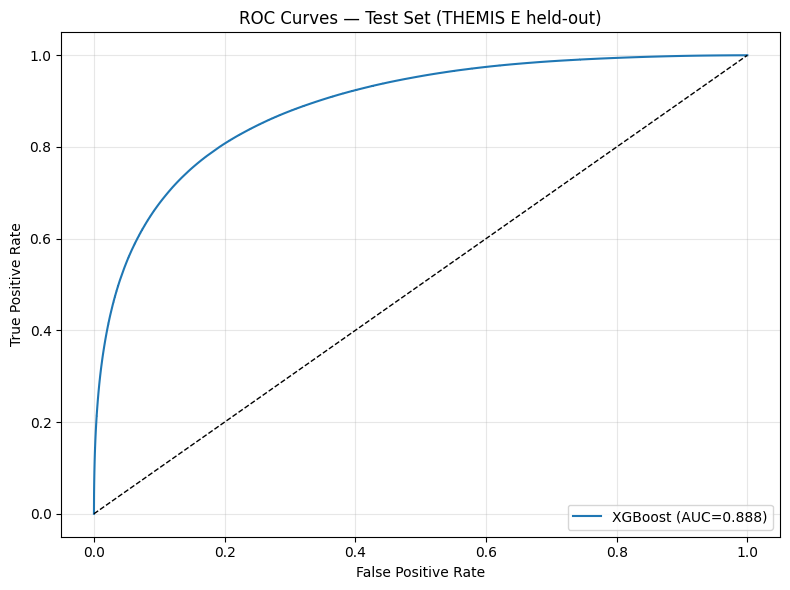

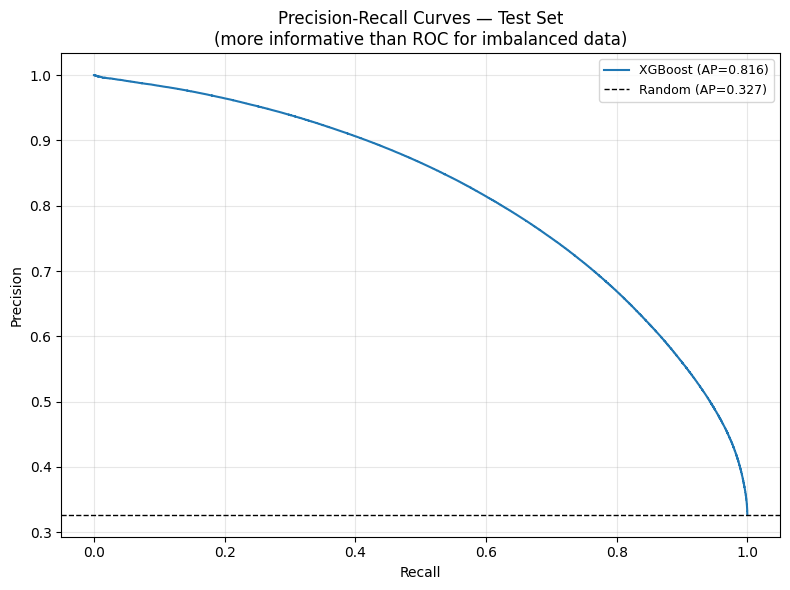

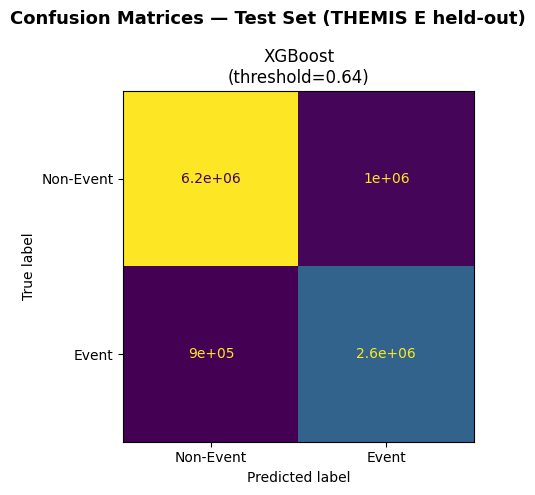


=== Feature Group Importance ===
  B Field   : 0.8004 (80.0%)
  Flux      : 0.1996 (20.0%)


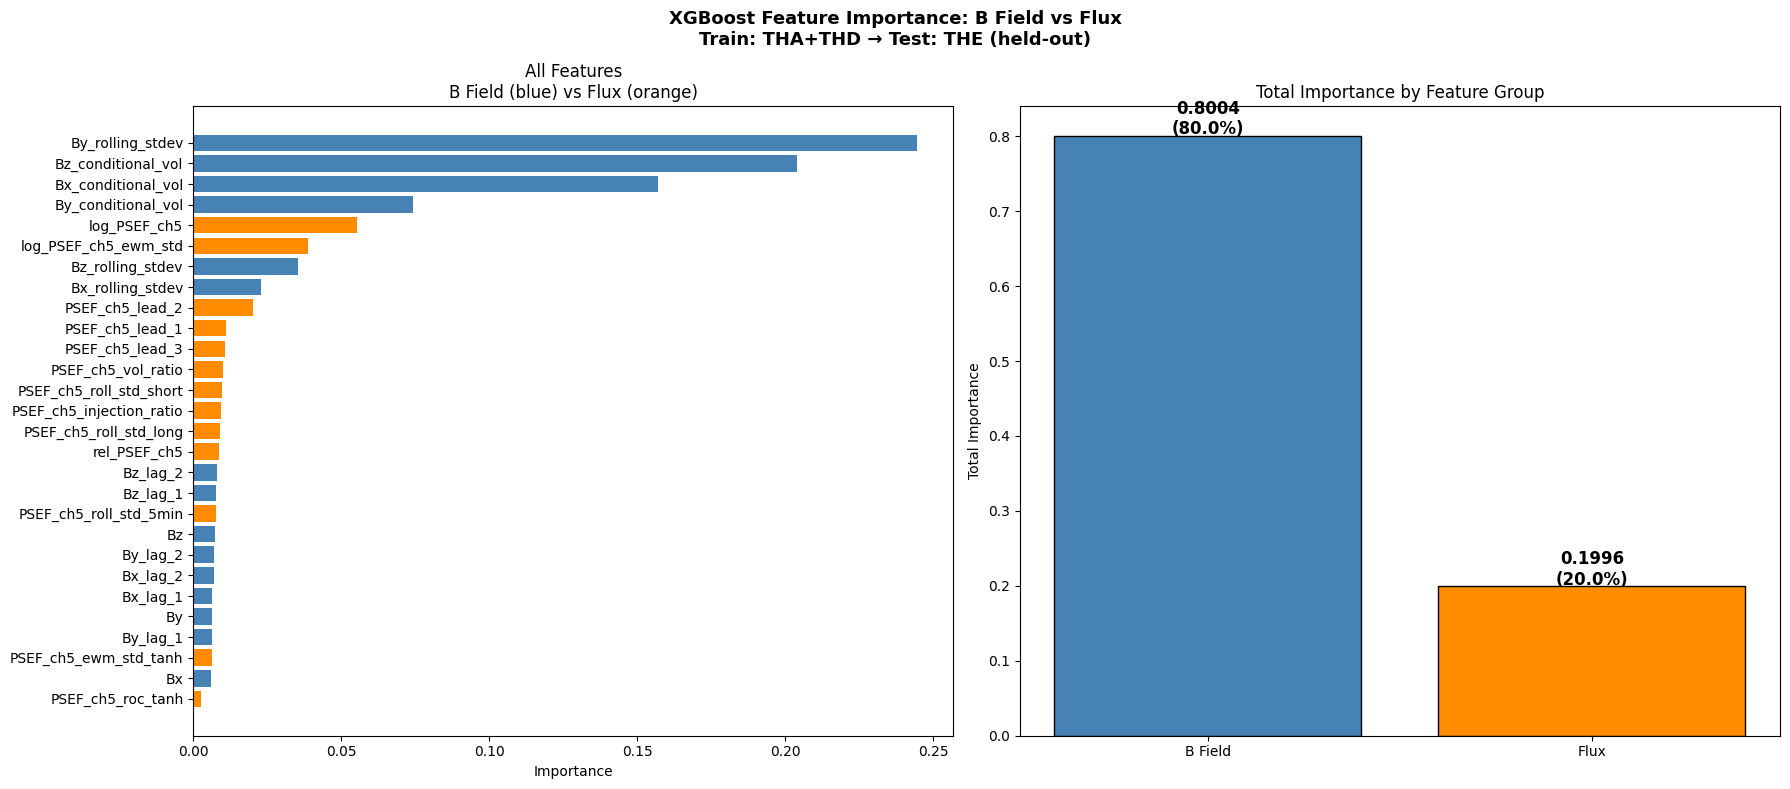

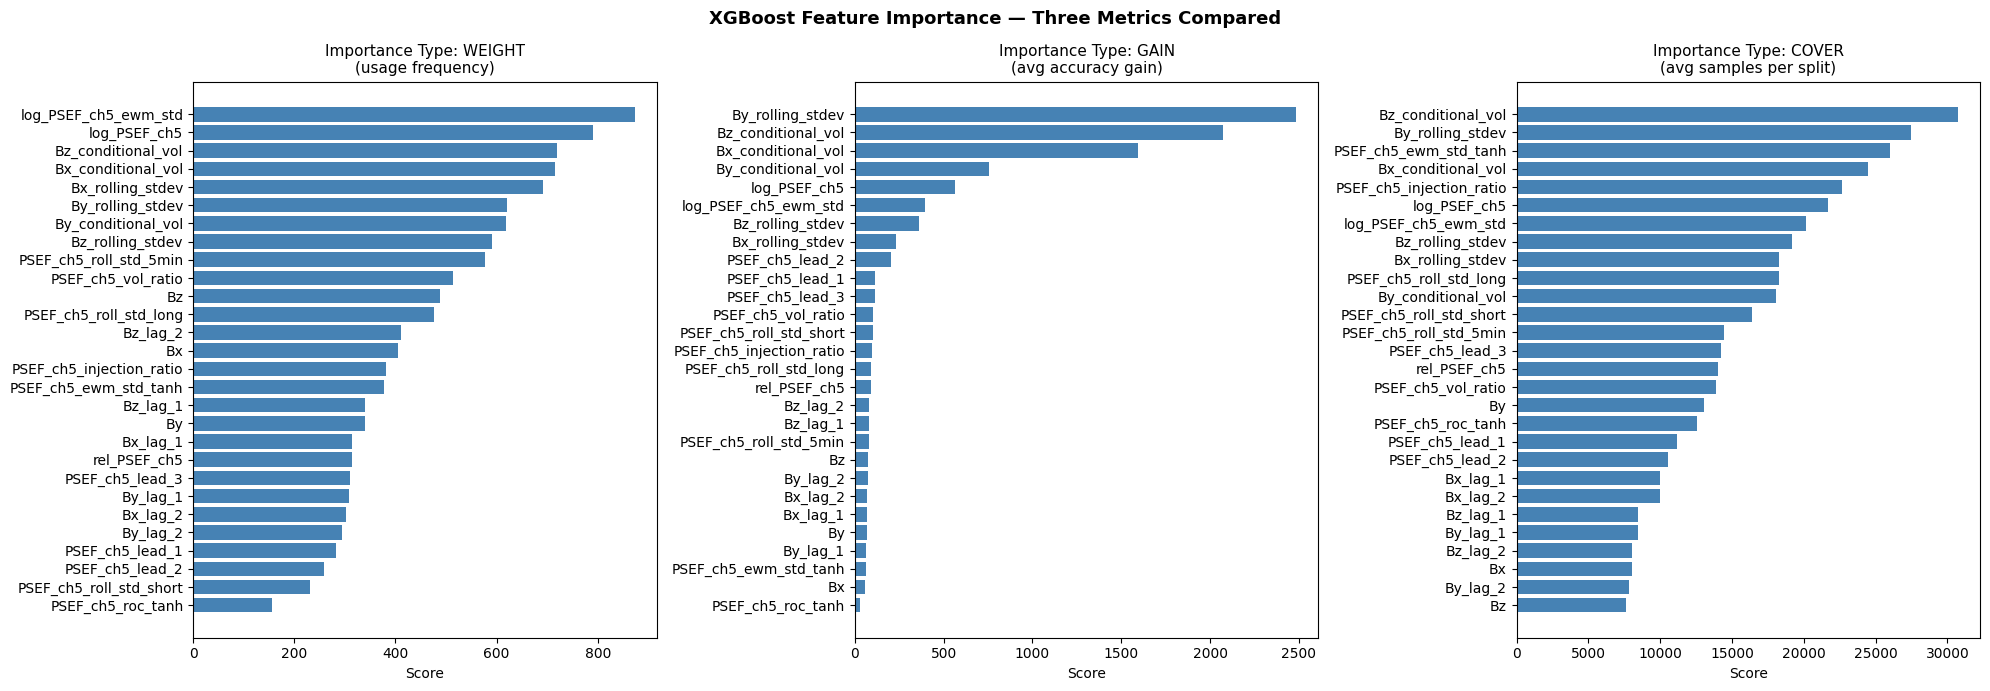

Tree plot failed: [04:51:03] /__w/xgboost/xgboost/src/tree/tree_model.cc:539: Failed to parse graphviz parameters:
	{"graph_attrs": {"rankdir": "LR", "feature_names": ["Bx", "By", "Bz", "Bx_lag_1", "Bx_lag_2", "By_lag_1", "By_lag_2", "Bz_lag_1", "Bz_lag_2", "Bx_conditional_vol", "By_conditional_vol", "Bz_conditional_vol", "Bx_rolling_stdev", "By_rolling_stdev", "Bz_rolling_stdev", "log_PSEF_ch5", "rel_PSEF_ch5", "PSEF_ch5_roll_std_short", "PSEF_ch5_roll_std_long", "PSEF_ch5_vol_ratio", "PSEF_ch5_ewm_std_tanh", "log_PSEF_ch5_ewm_std", "PSEF_ch5_roc_tanh", "PSEF_ch5_roll_std_5min", "PSEF_ch5_injection_ratio", "PSEF_ch5_lead_1", "PSEF_ch5_lead_2", "PSEF_ch5_lead_3"]}}
With error:
[04:51:03] /__w/xgboost/xgboost/dmlc-core/include/dmlc/./json.h:674: Check failed: ch == '\"' (91 vs. ") : Error at Line 0, around ^`"Bx", "By", "Bz", "Bx_lag_1", "Bx_lag_2", "By_lag_1", "By_lag_2`, Expect '"' but get '['
Stack trace:
  [bt] (0) /usr/local/lib/python3.12/dist-packages/xgboost/lib/libxgboost.so(+0

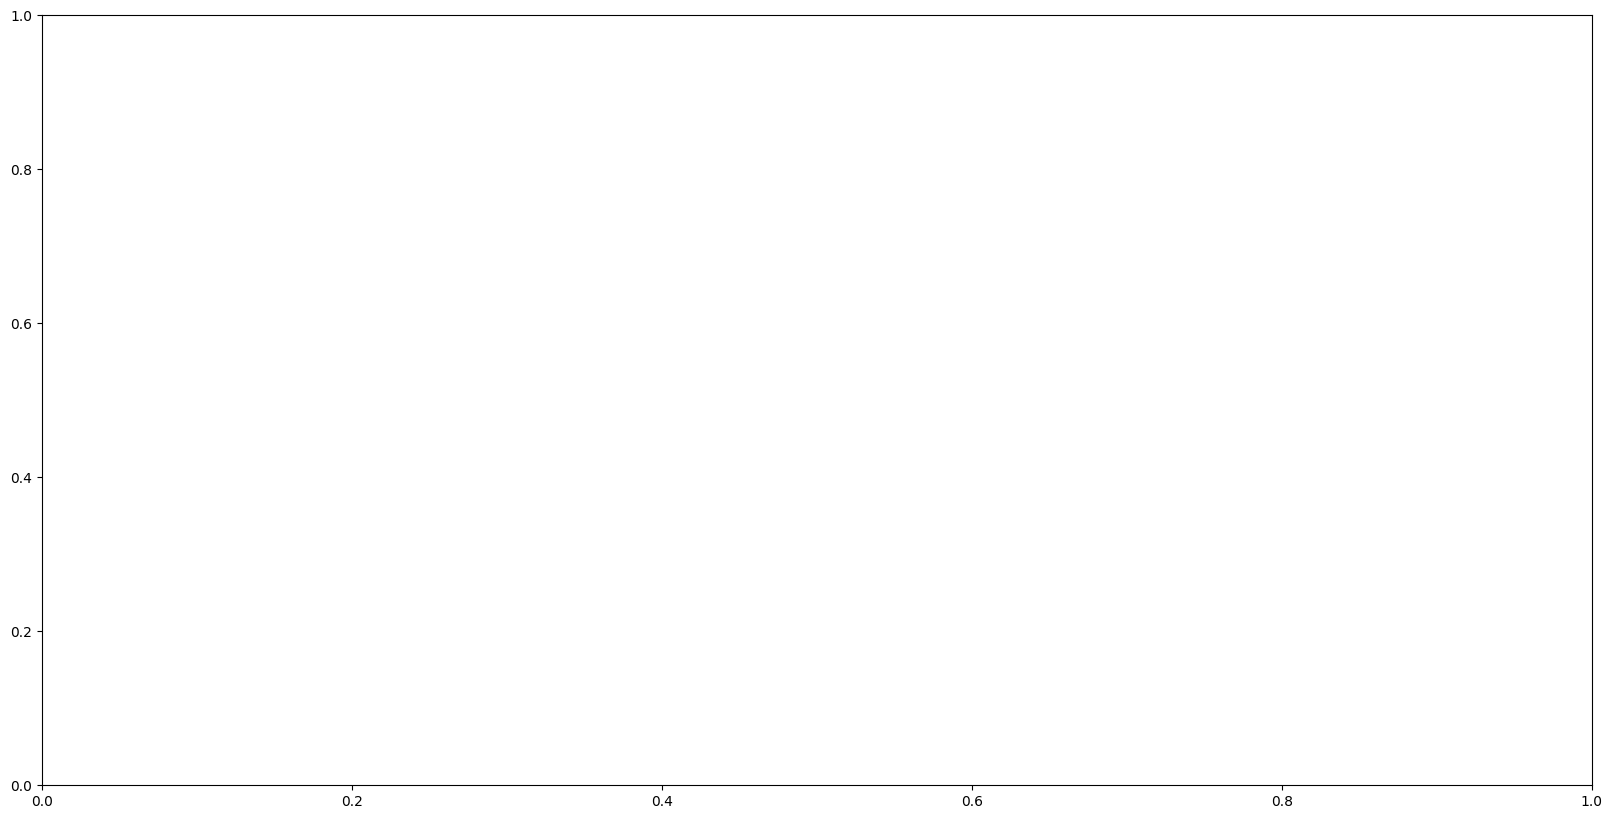

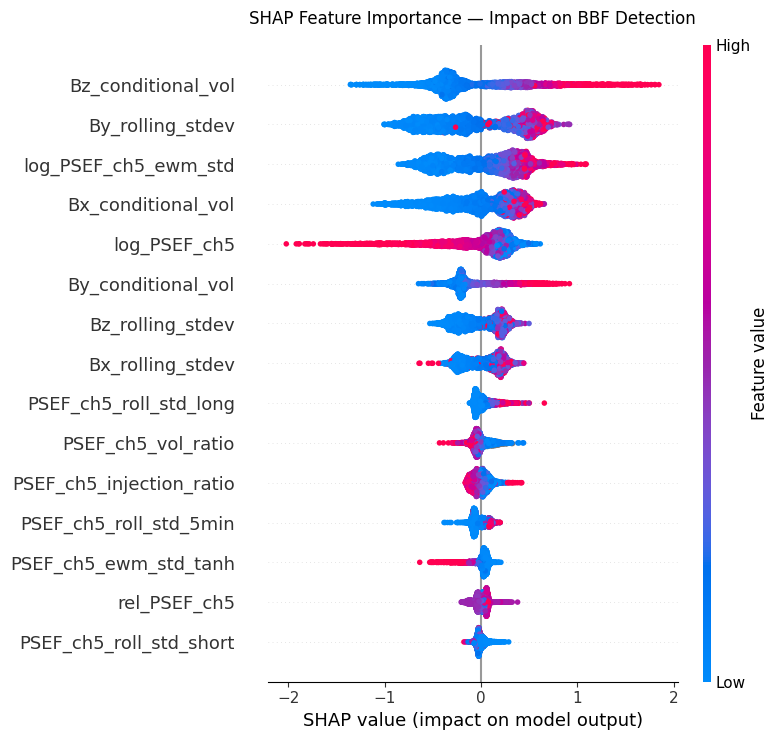

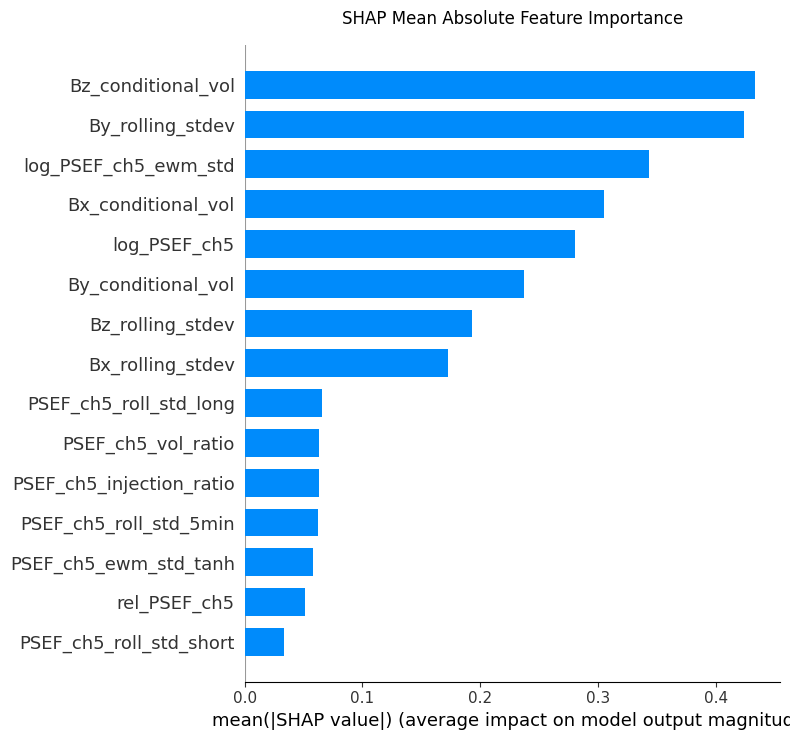

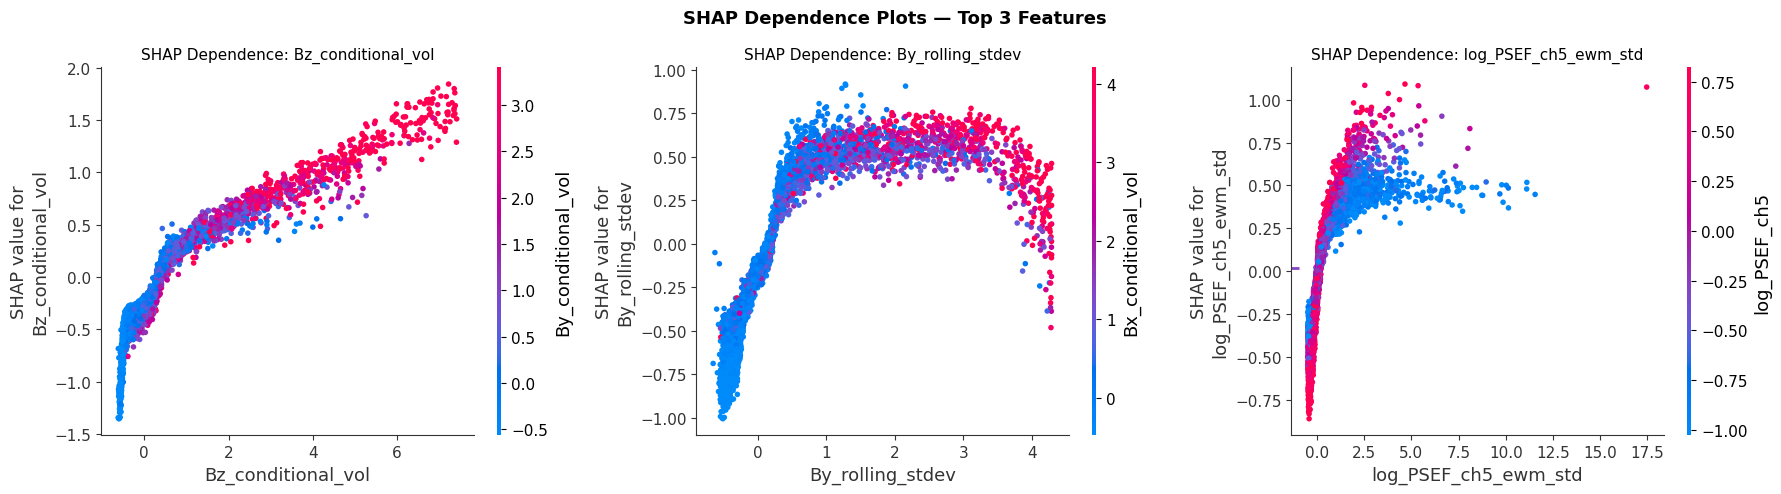

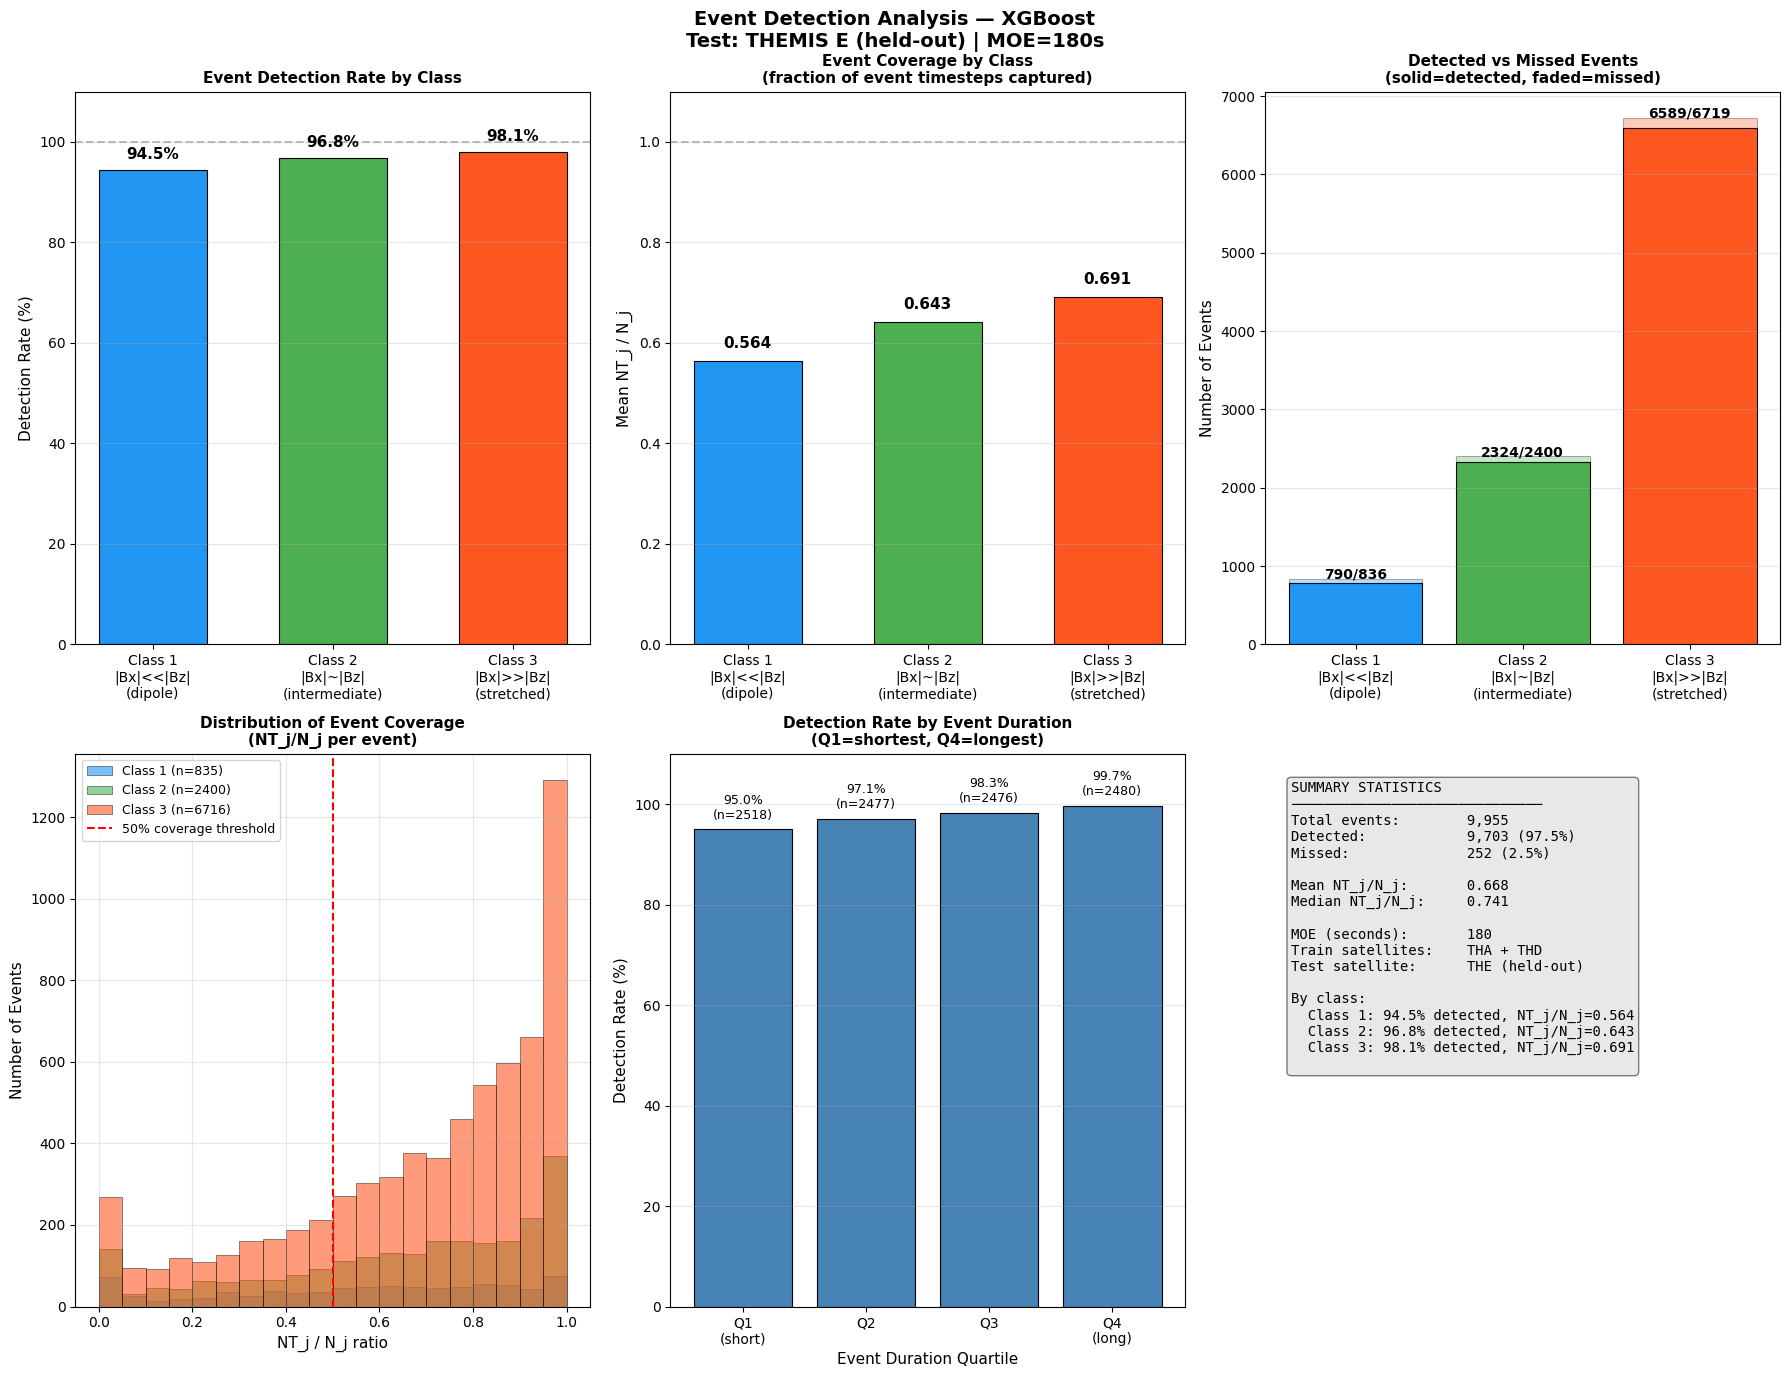

Event detection plot saved.

════════════════════════════════════════════════════════════════════════════════
FINAL MODEL COMPARISON
Train: THA + THD ([2008, 2009, 2010, 2011, 2012, 2013, 2014, 2015, 2016])
Val:   THA + THD ([2017, 2018, 2019, 2020, 2021])
Test:  THEMIS E — ALL years (held-out satellite)
Threshold tuned on validation — NEVER on test set
════════════════════════════════════════════════════════════════════════════════
  Model  Threshold  ROC-AUC  Avg Precision  F1 (timestep)  Event Detect %  Mean NT_j/N_j
XGBoost       0.64   0.8884         0.8161         0.7301            97.5         0.6685

Past team reference (shuffled data + threshold tuned on test):
  Reported accuracy: 0.82  ← inflated due to data leakage

Canonical THE test set locked: 10,629,407 rows
Run 1 memory freed. Ready for Run 2.


In [ ]:
import copy
import gc

# ── RUN 1: B-field + electron flux ───────────────────────────────────────────
print("=" * 70)
print("RUN 1: B-field + Electron Flux (establishes canonical test set)")
print("=" * 70)

CONFIG_FLUX = copy.deepcopy(CONFIG)
CONFIG_FLUX['include_flux']        = True
CONFIG_FLUX['flux_coverage_years'] = list(range(2008, 2022))
CONFIG_FLUX['feature_cols']        = B_FEATURE_COLS + FLUX_FEATURE_COLS

results_flux = run_pipeline(config=CONFIG_FLUX, train_neural_net_flag=False)

# ── Lock canonical epochs ─────────────────────────────────────────────────────
canonical_test_epochs = set(
    results_flux['splits']['test']['Epoch_time'].values
)
print(f"\nCanonical THE test set locked: {len(canonical_test_epochs):,} rows")

# ── Free everything heavy from Run 1 ─────────────────────────────────────────
# Keep results_flux['all_results'] for the final table but drop the big splits
del results_flux['splits']
for r in results_flux['all_results']:
    del r['y_test'], r['y_test_pred']
gc.collect()
print("Run 1 memory freed. Ready for Run 2.")

RUN 2: B-field ONLY — restricted to canonical test set
Loading event catalog...
Lazy loading parquet (Dask)...
Force train years override: [2008, 2009, 2010, 2011, 2012, 2013, 2014, 2015, 2016]
Force val years override: [2017, 2018, 2019, 2020, 2021]

Temporal sampling enabled.
Train years kept: [2008, 2009, 2010, 2011, 2012, 2013, 2014, 2015, 2016]
Val years kept:   [2017, 2018, 2019, 2020, 2021]

Computing THA+THD...
THA+THD rows: 32,048,604
Computing THE...
THE rows: 16,721,136

THA+THD rows: 32,048,604
THE rows:     16,721,136

Loaded: (48769740, 20)
Memory: 6.25 GB
Satellites: {'THEMIS E': 16721136, 'THEMIS A': 16421321, 'THEMIS D': 15627283}
Label balance: {0: 0.661, 1: 0.339}

Splitting data...
  Canonical epoch filter: 16,721,136 → 10,629,407 THE rows
  Train ends:          2016-12-31 23:59:57.373389482+00:00
  Val starts:          2017-01-01 00:00:00.135007381+00:00
  Temporal integrity:  ✓ PASSED

  Train breakdown:
    THEMIS A: 8,659,256 (50.1%)
    THEMIS D: 8,641,508 (49.

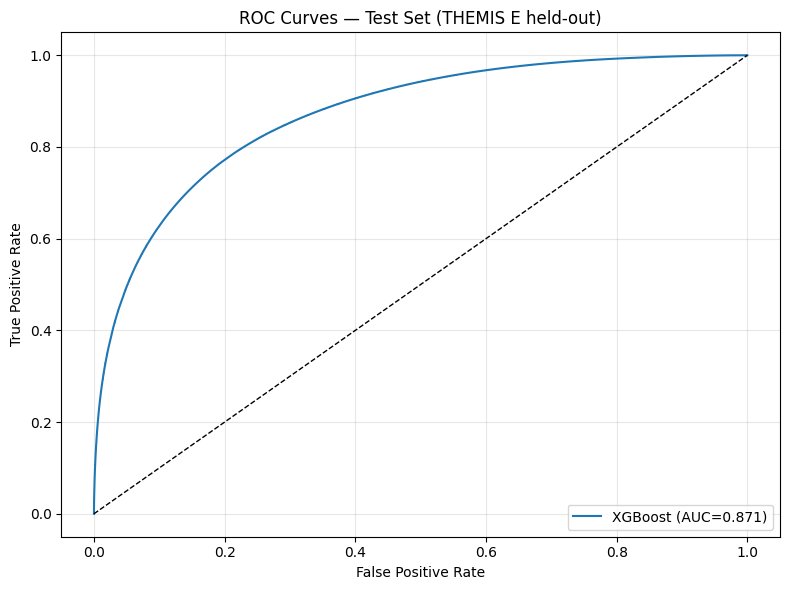

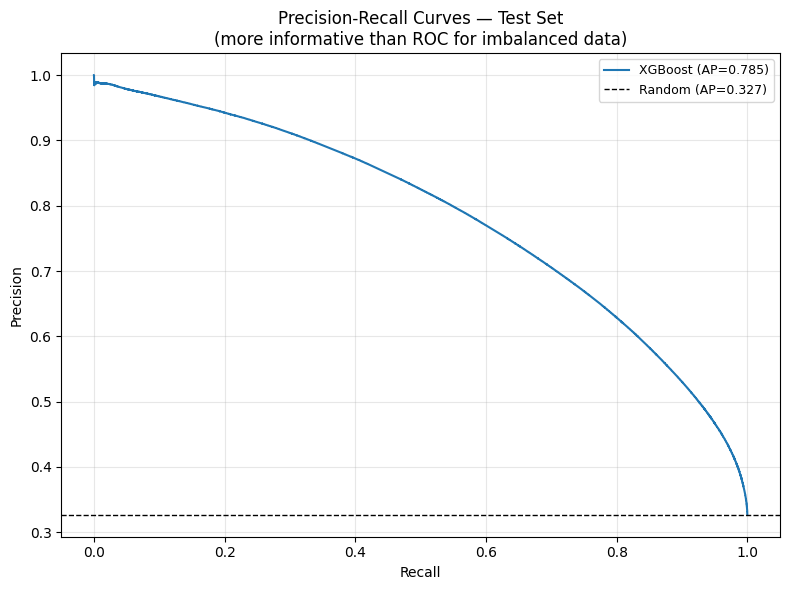

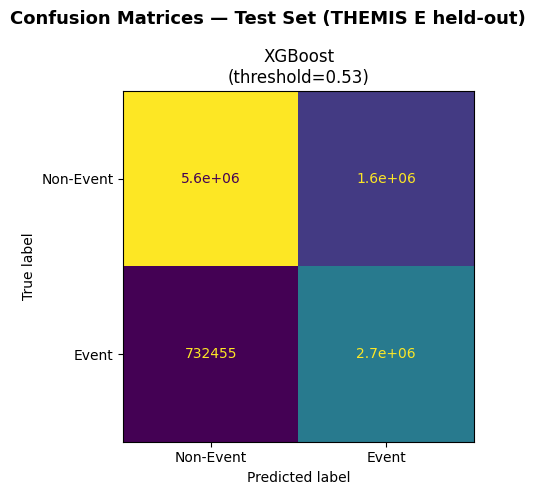

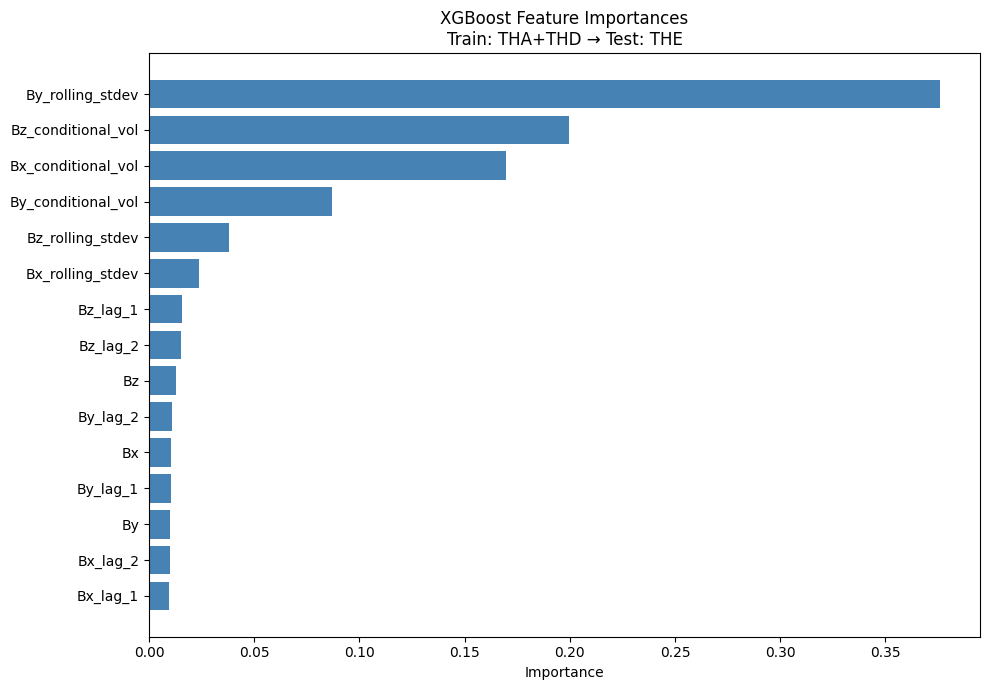


Top 10 features:
           Feature  Importance
  By_rolling_stdev    0.376169
Bz_conditional_vol    0.199852
Bx_conditional_vol    0.169681
By_conditional_vol    0.087153
  Bz_rolling_stdev    0.037900
  Bx_rolling_stdev    0.023707
          Bz_lag_1    0.015716
          Bz_lag_2    0.015126
                Bz    0.013004
          By_lag_2    0.010934


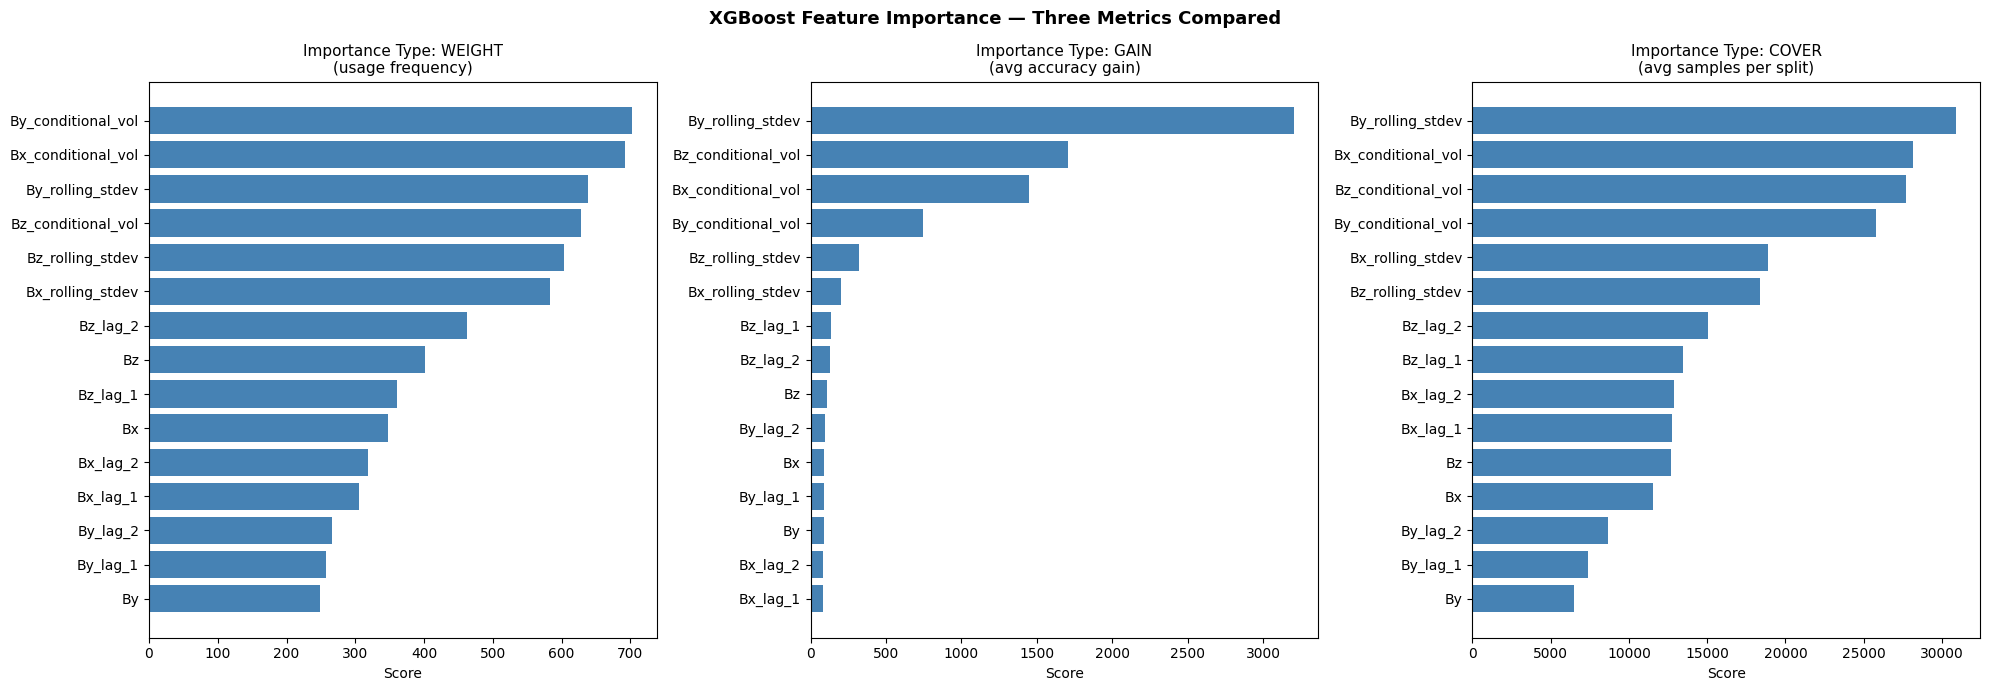

Tree plot failed: [04:55:15] /__w/xgboost/xgboost/src/tree/tree_model.cc:539: Failed to parse graphviz parameters:
	{"graph_attrs": {"rankdir": "LR", "feature_names": ["Bx", "By", "Bz", "Bx_lag_1", "Bx_lag_2", "By_lag_1", "By_lag_2", "Bz_lag_1", "Bz_lag_2", "Bx_conditional_vol", "By_conditional_vol", "Bz_conditional_vol", "Bx_rolling_stdev", "By_rolling_stdev", "Bz_rolling_stdev"]}}
With error:
[04:55:15] /__w/xgboost/xgboost/dmlc-core/include/dmlc/./json.h:674: Check failed: ch == '\"' (91 vs. ") : Error at Line 0, around ^`"Bx", "By", "Bz", "Bx_lag_1", "Bx_lag_2", "By_lag_1", "By_lag_2`, Expect '"' but get '['
Stack trace:
  [bt] (0) /usr/local/lib/python3.12/dist-packages/xgboost/lib/libxgboost.so(+0x2c1a8c) [0x7a4b2b2c1a8c]
  [bt] (1) /usr/local/lib/python3.12/dist-packages/xgboost/lib/libxgboost.so(+0x9a5de0) [0x7a4b2b9a5de0]
  [bt] (2) /usr/local/lib/python3.12/dist-packages/xgboost/lib/libxgboost.so(+0x9b4e3b) [0x7a4b2b9b4e3b]
  [bt] (3) /usr/local/lib/python3.12/dist-packages/x

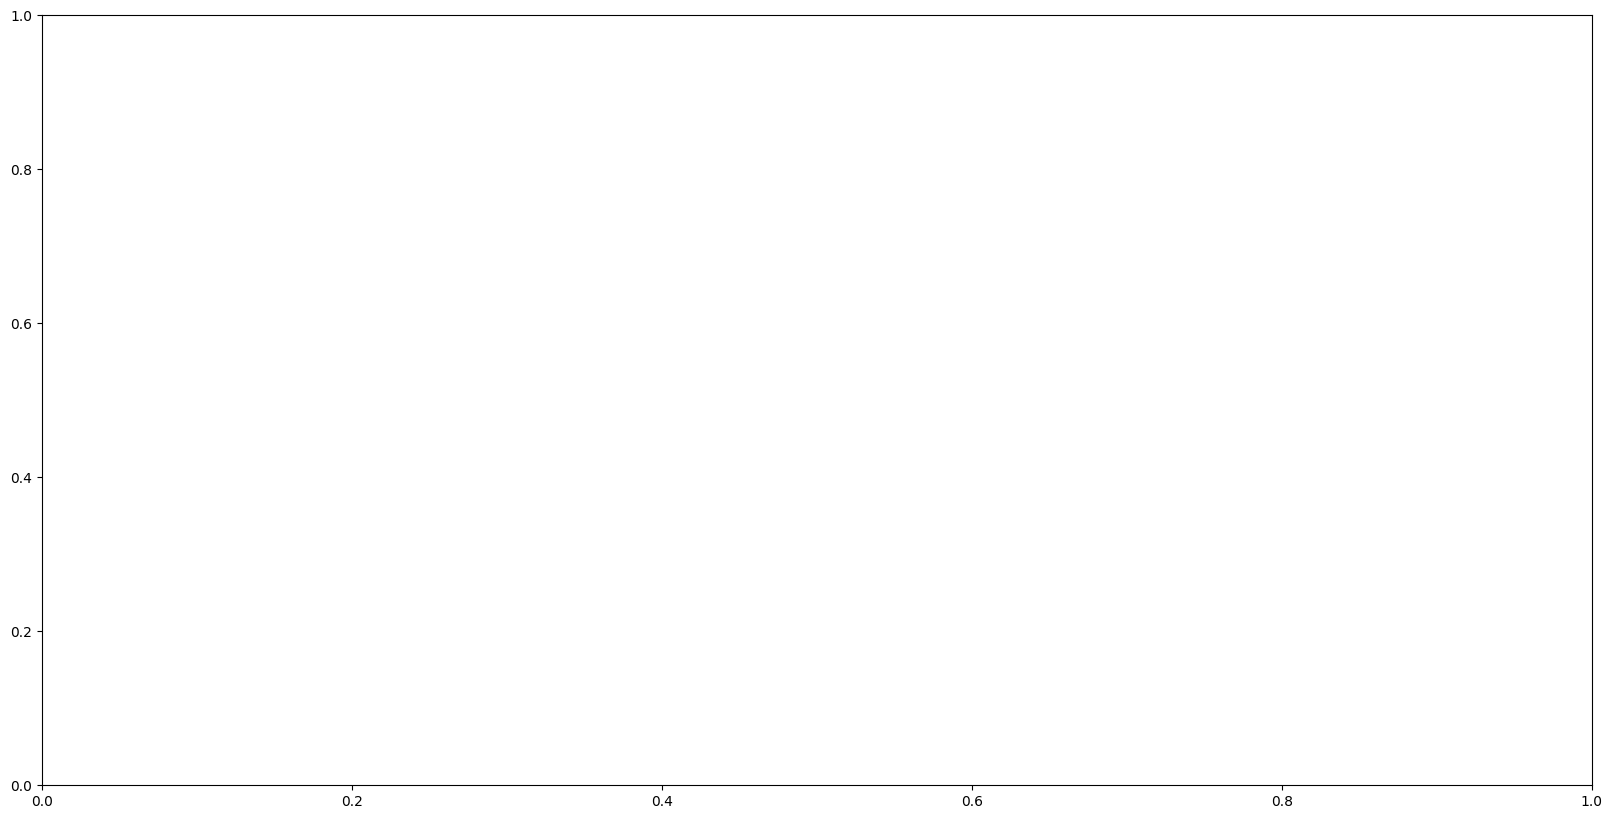

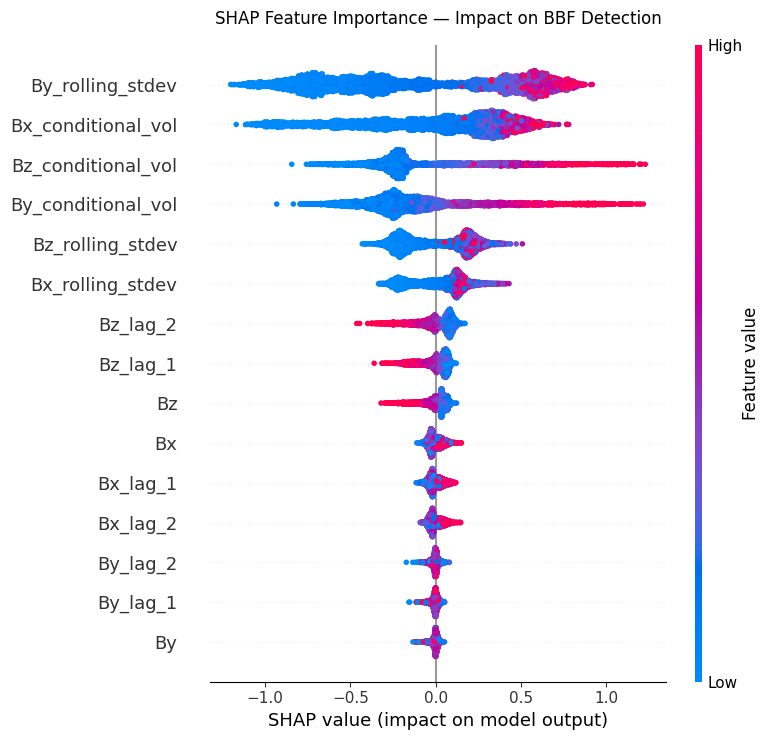

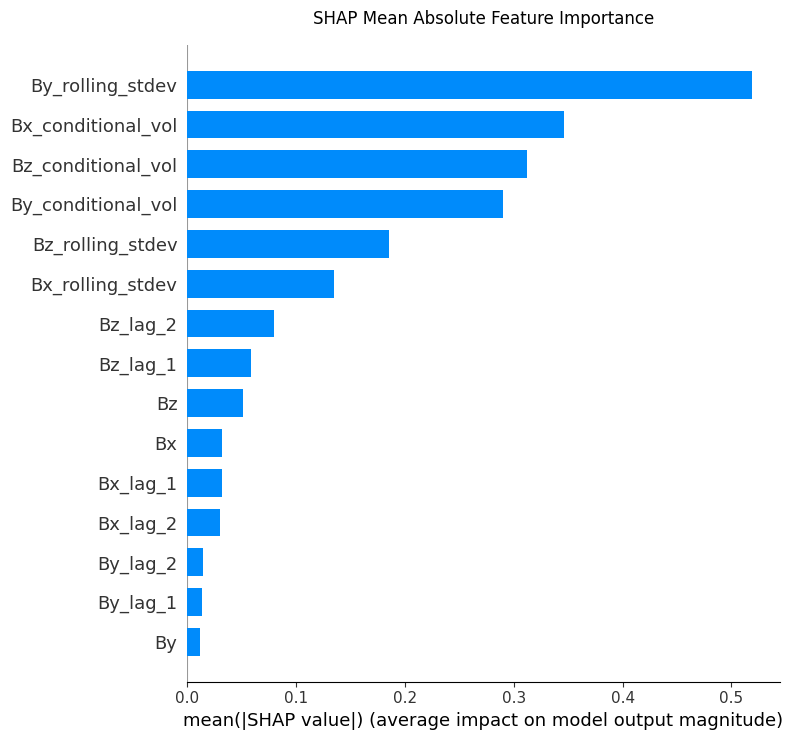

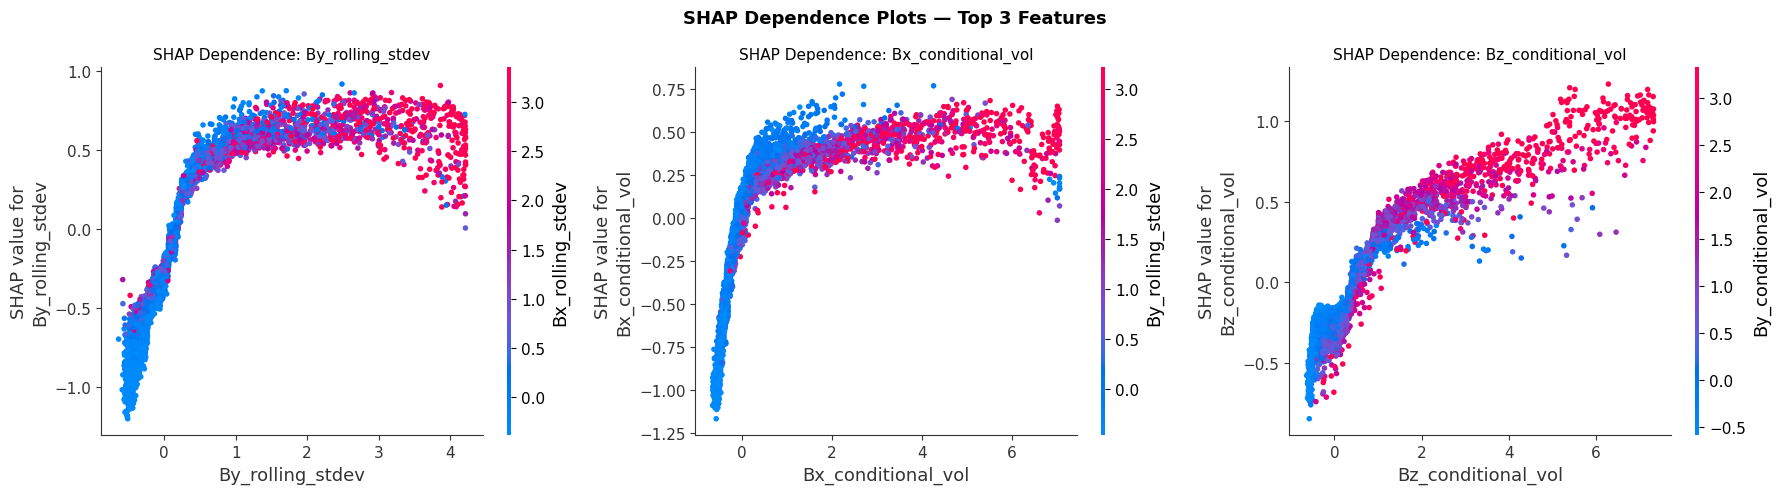

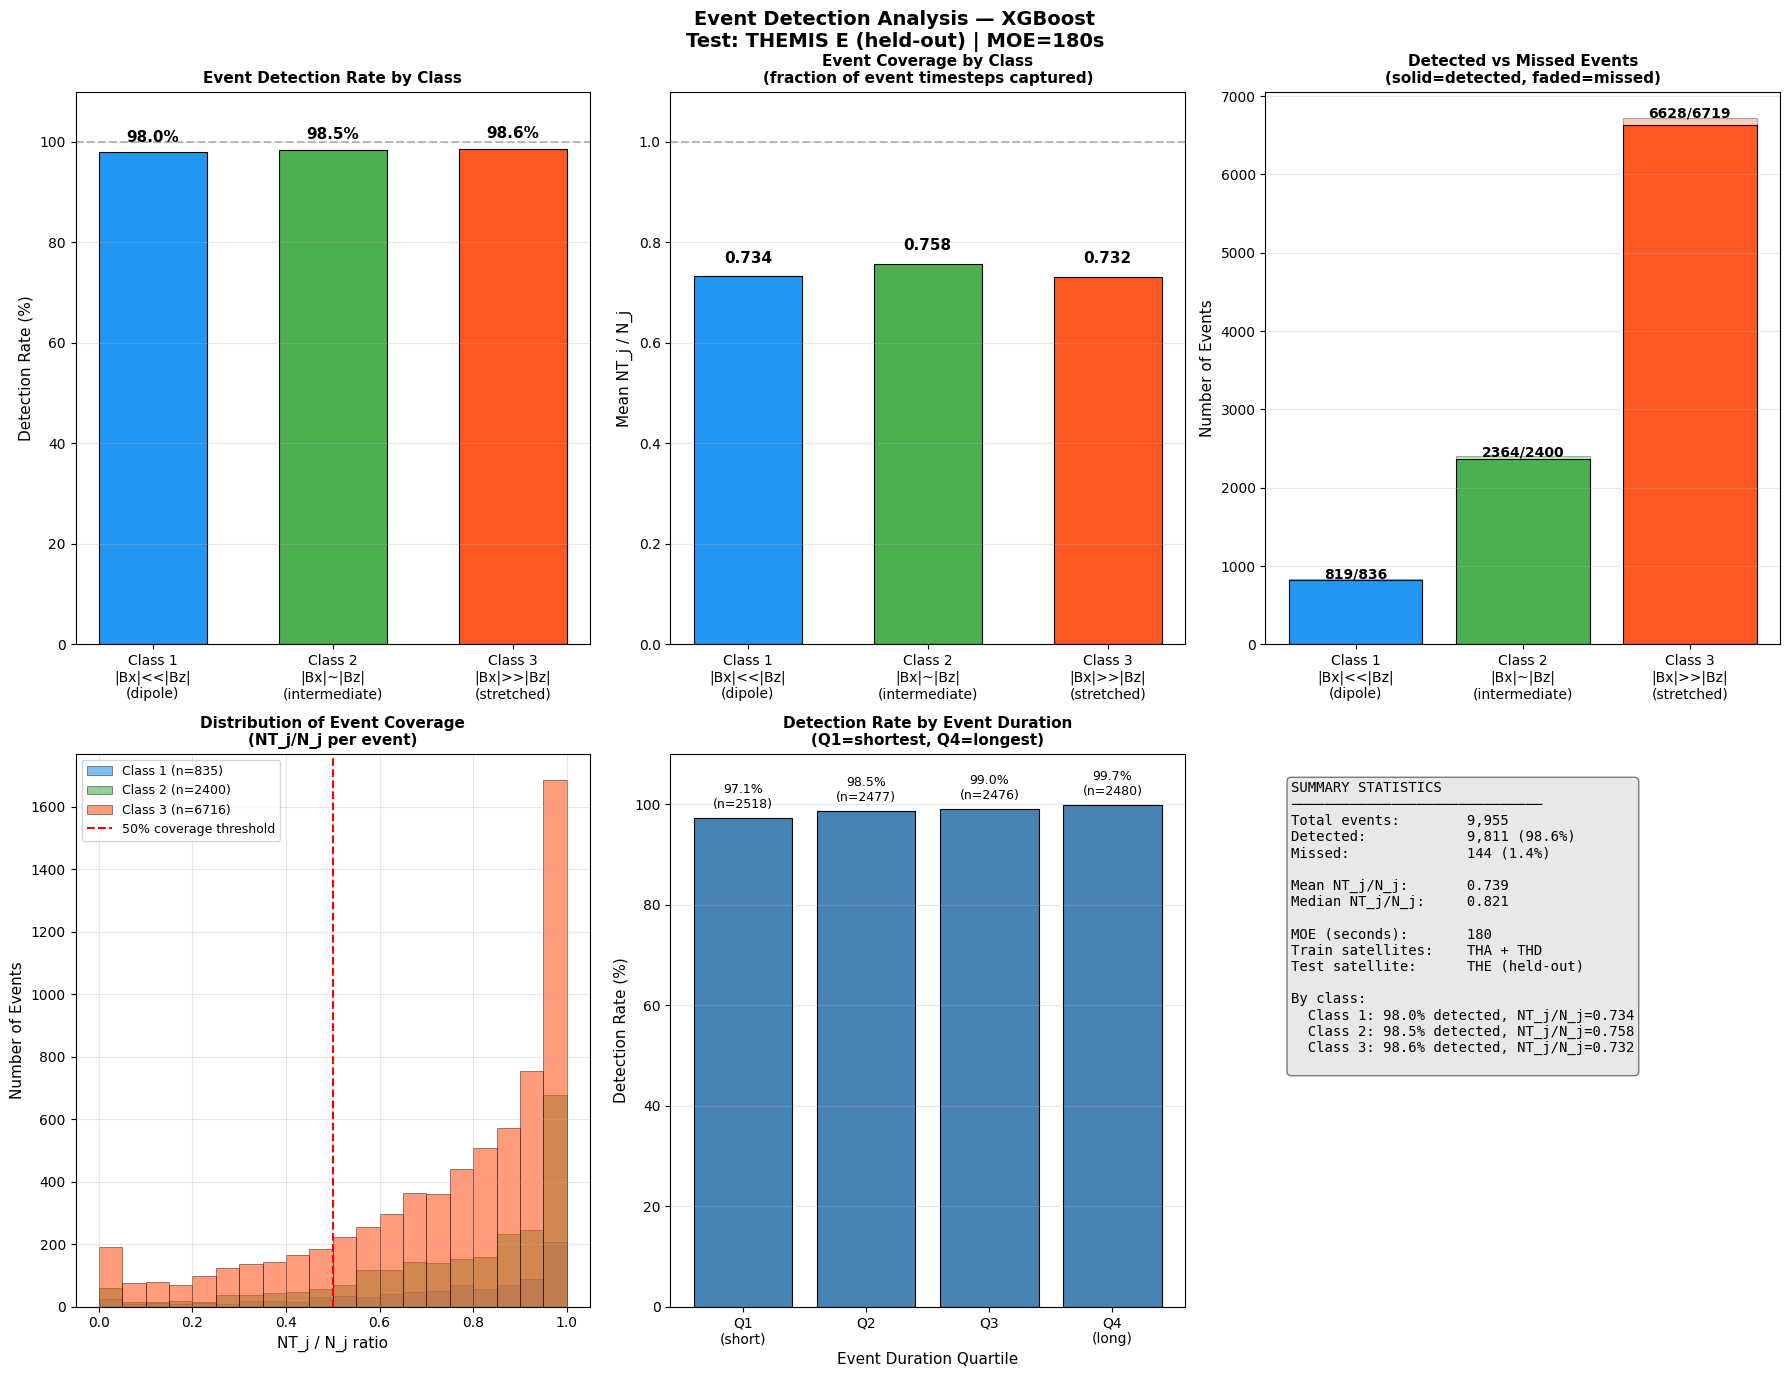

Event detection plot saved.

════════════════════════════════════════════════════════════════════════════════
FINAL MODEL COMPARISON
Train: THA + THD ([2008, 2009, 2010, 2011, 2012, 2013, 2014, 2015, 2016])
Val:   THA + THD ([2017, 2018, 2019, 2020, 2021])
Test:  THEMIS E — ALL years (held-out satellite)
Threshold tuned on validation — NEVER on test set
════════════════════════════════════════════════════════════════════════════════
  Model  Threshold  ROC-AUC  Avg Precision  F1 (timestep)  Event Detect %  Mean NT_j/N_j
XGBoost       0.53   0.8705          0.785         0.7055            98.6         0.7386

Past team reference (shuffled data + threshold tuned on test):
  Reported accuracy: 0.82  ← inflated due to data leakage

══════════════════════════════════════════════════════════════════════
CONTROLLED ABLATION RESULTS — IDENTICAL TEST SET
══════════════════════════════════════════════════════════════════════
Model                                Test Rows   ROC-AUC  Avg Prec     

70893

In [ ]:
import gc

# ── RUN 2: B-field only, restricted to canonical test set ────────────────────
print("=" * 70)
print("RUN 2: B-field ONLY — restricted to canonical test set")
print("=" * 70)

CONFIG_BONLY = copy.deepcopy(CONFIG)
CONFIG_BONLY['include_flux']          = False
CONFIG_BONLY['feature_cols']          = B_FEATURE_COLS
CONFIG_BONLY['canonical_test_epochs'] = canonical_test_epochs
CONFIG_BONLY['flux_coverage_years']   = list(range(2008, 2022))

results_bonly = run_pipeline(config=CONFIG_BONLY, train_neural_net_flag=False)

# ── Final comparison table ────────────────────────────────────────────────────
print("\n" + "═" * 70)
print("CONTROLLED ABLATION RESULTS — IDENTICAL TEST SET")
print("═" * 70)
print(f"{'Model':<35} {'Test Rows':>10} {'ROC-AUC':>9} {'Avg Prec':>9} "
      f"{'F1':>7} {'Thresh':>7} {'Detect%':>8} {'NT_j/N_j':>9}")
print("─" * 70)

n_test_flux  = len(results_bonly['splits']['test'])  # both sets identical
n_test_bonly = len(results_bonly['splits']['test'])

for label, results, n_test in [
    ("XGBoost — B-field + Electron Flux", results_flux,  n_test_flux),
    ("XGBoost — B-field Only",            results_bonly, n_test_bonly)
]:
    for r in results['all_results']:
        print(f"{label:<35} {n_test:>10,} {r['roc_auc']:>9.4f} "
              f"{r['avg_precision']:>9.4f} {r['f1_timestep']:>7.4f} "
              f"{r['threshold']:>7.2f} {r['event_detection_rate']*100:>7.1f}% "
              f"{r['mean_nt_nj']:>9.4f}")

gc.collect()

In [ ]:
from sklearn.metrics import precision_recall_curve, roc_auc_score, average_precision_score

# ── Threshold-free metrics (always fair) ─────────────────────────────────────
print("\n" + "═" * 70)
print("PART 1: THRESHOLD-FREE METRICS (primary comparison)")
print("Evaluated across all thresholds simultaneously — fully comparable")
print("═" * 70)
print(f"{'Model':<35} {'Test Rows':>10} {'ROC-AUC':>9} {'Avg Precision':>14}")
print("─" * 70)

n_test = len(results_bonly['splits']['test'])
y_test_true  = results_bonly['all_results'][0]['y_test']
flux_proba   = results_flux['all_results'][0]['y_test_proba']
bonly_proba  = results_bonly['all_results'][0]['y_test_proba']

flux_auc   = results_flux['all_results'][0]['roc_auc']
flux_ap    = results_flux['all_results'][0]['avg_precision']
bonly_auc  = results_bonly['all_results'][0]['roc_auc']
bonly_ap   = results_bonly['all_results'][0]['avg_precision']

print(f"{'XGBoost — B + Electron Flux':<35} {n_test:>10,} {flux_auc:>9.4f} {flux_ap:>14.4f}")
print(f"{'XGBoost — B Only':<35} {n_test:>10,} {bonly_auc:>9.4f} {bonly_ap:>14.4f}")
print(f"{'Δ (Flux - B Only)':<35} {'':>10} {flux_auc-bonly_auc:>+9.4f} {flux_ap-bonly_ap:>+14.4f}")

# ── Fixed recall comparison (apples to apples) ────────────────────────────────
print("\n" + "═" * 70)
print("PART 2: FIXED RECALL OPERATING POINTS (threshold-controlled comparison)")
print("Both models evaluated at identical sensitivity levels")
print("═" * 70)

prec_flux,  rec_flux,  thresh_flux  = precision_recall_curve(y_test_true, flux_proba)
prec_bonly, rec_bonly, thresh_bonly = precision_recall_curve(y_test_true, bonly_proba)

target_recalls = [0.70, 0.75, 0.80, 0.85]

print(f"\n  {'Recall':>8} {'Thresh(Flux)':>13} {'Prec(Flux)':>11} "
      f"{'Thresh(BOnly)':>14} {'Prec(BOnly)':>12} {'Δ Precision':>12}")
print(f"  {'─' * 75}")

for target in target_recalls:
    idx_flux  = np.argmin(np.abs(rec_flux  - target))
    idx_bonly = np.argmin(np.abs(rec_bonly - target))

    t_flux    = thresh_flux[min(idx_flux,  len(thresh_flux)  - 1)]
    t_bonly   = thresh_bonly[min(idx_bonly, len(thresh_bonly) - 1)]
    p_flux    = prec_flux[idx_flux]
    p_bonly   = prec_bonly[idx_bonly]

    print(f"  {target:>8.2f} {t_flux:>13.4f} {p_flux:>11.4f} "
          f"{t_bonly:>14.4f} {p_bonly:>12.4f} {p_flux - p_bonly:>+12.4f}")

# ── Event level at matched recall ────────────────────────────────────────────
print("\n" + "═" * 70)
print("PART 3: EVENT-LEVEL at Recall = 0.75 (matched operating point)")
print("═" * 70)

TARGET_RECALL = 0.75

idx_flux  = np.argmin(np.abs(rec_flux  - TARGET_RECALL))
idx_bonly = np.argmin(np.abs(rec_bonly - TARGET_RECALL))
t_flux    = thresh_flux[min(idx_flux,   len(thresh_flux)  - 1)]
t_bonly   = thresh_bonly[min(idx_bonly, len(thresh_bonly) - 1)]

print(f"\n  Flux  threshold at recall={TARGET_RECALL}: {t_flux:.4f}")
print(f"  BOnly threshold at recall={TARGET_RECALL}: {t_bonly:.4f}")

# Re-evaluate event level at matched thresholds
for label, proba, thresh, config_used, results_used in [
    ("B + Electron Flux", flux_proba,  t_flux,  CONFIG_FLUX,  results_flux),
    ("B Only",            bonly_proba, t_bonly, CONFIG_BONLY, results_bonly),
]:
    y_pred_matched = (proba >= thresh).astype(int)
    test_df_used   = results_bonly['splits']['test']  # identical for both
    event_df_reload = pd.read_csv(CONFIG['event_path'])
    event_df_reload['start_time'] = pd.to_datetime(event_df_reload['start_time'], utc=True)
    event_df_reload['end_time']   = pd.to_datetime(event_df_reload['end_time'],   utc=True)

    print(f"\n  ── {label} (threshold={thresh:.4f}) ──")
    event_res = evaluate_event_level(
        test_df_used, y_pred_matched, event_df_reload, config_used
    )


══════════════════════════════════════════════════════════════════════
PART 1: THRESHOLD-FREE METRICS (primary comparison)
Evaluated across all thresholds simultaneously — fully comparable
══════════════════════════════════════════════════════════════════════
Model                                Test Rows   ROC-AUC  Avg Precision
──────────────────────────────────────────────────────────────────────
XGBoost — B + Electron Flux         10,629,407    0.8884         0.8161
XGBoost — B Only                    10,629,407    0.8705         0.7850
Δ (Flux - B Only)                                +0.0179        +0.0312

══════════════════════════════════════════════════════════════════════
PART 2: FIXED RECALL OPERATING POINTS (threshold-controlled comparison)
Both models evaluated at identical sensitivity levels
══════════════════════════════════════════════════════════════════════

    Recall  Thresh(Flux)  Prec(Flux)  Thresh(BOnly)  Prec(BOnly)  Δ Precision
  ──────────────────────────────